In [1]:
import numpy as np
import mo_gymnasium as mo_gym
from scipy.optimize import minimize, LinearConstraint, Bounds
from numpy.linalg import matrix_rank, pinv
import matplotlib.pyplot as plt

from morl_baselines.multi_policy.linear_support.linear_support import LinearSupport

import torch.nn as nn
# from tqdm.auto import tqdm
from IPython import display
from itertools import product

import torch
import torch.nn.functional as F

from scipy.interpolate import PchipInterpolator

import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors

import matplotlib as mpl
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

from datetime import datetime
import time

In [2]:
DEVICE = "cpu" # torch.device("mps" if torch.backends.mps.is_available() else "cpu")
# print(DEVICE)

FIG_PATH = "figure/"

plt.rcParams.update({
    # Figure
    "figure.figsize": (6, 4),
    "figure.dpi": 120,

    # Font
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "legend.fontsize": 16,

    # Lines
    "lines.linewidth": 2.0,
    "lines.markersize": 12,

    # Axes
    "axes.grid": True,
    "grid.linestyle": ":",
    "grid.alpha": 0.5,

    # Ticks
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,

    # Legend
    "legend.frameon": False,

    # Layout
    "figure.autolayout": True
})

METHOD_COLORS = {
    "Ours": "#d62728",
    r"Uniform-$w$": "#1f77b4",   # soft blue
    "OLS": "#2ca02c",        # soft orange
    "Soup": "#9467bd",        # soft orange
    "UMOD": "#ff7f0e",
}

METHOD_MARKERS = {
    "Ours": "o",
    r"Uniform-$w$": "s",   # soft blue
    "OLS": "o",        # soft orange
    "Soup": "D",        # soft orange
    "UMOD": "v",
}


### DST problem setting

In [3]:
#  A. Build a tabular DST model from MO-Gymnasium
def get_dst_grid(env):
    uenv = env.unwrapped
    candidate_names = ["sea_map", "dst_map", "map", "_map", "grid", "treasure_map"]
    for name in candidate_names:
        if hasattr(uenv, name):
            arr = np.array(getattr(uenv, name))
            if arr.ndim == 2:
                return arr, name
    raise AttributeError("Could not find a 2D map attribute in env.unwrapped.")


def build_dst_tabular_model(env):
    """
    Build a deterministic tabular model for Deep-Sea-Treasure.

    Returns
    -------
    model : dict
        {
            "states": list of (r, c) + [("terminal",)],
            "state_to_idx": dict,
            "idx_to_state": dict,
            "S": int,
            "A": int,
            "P": np.ndarray of shape (S, A, S),
            "R": np.ndarray of shape (S, A, 2),
            "rho0": np.ndarray of shape (S,),
            "terminal_idx": int,
            "treasure_mask": np.ndarray of shape (S,),
            "valid_mask": np.ndarray of shape (S, A),
        }
    """
    grid, grid_name = get_dst_grid(env)
    nrow, ncol = grid.shape

    # Convention:
    # - sea cells: 0
    # - treasure cells: positive
    # - blocked cells: usually -10 or similar in some implementations
    # We treat positive cells as treasure/terminal-on-entry.
    # Everything else except hard-blocked cells is traversable.
    def is_blocked(v):
        # adjust if needed after inspecting Our exact map
        return v == -10

    def is_treasure(v):
        return v > 0

    states = []
    for r in range(nrow):
        for c in range(ncol):
            if not is_blocked(grid[r, c]):
                states.append((r, c))

    terminal_state = ("terminal",)
    states.append(terminal_state)

    state_to_idx = {s: i for i, s in enumerate(states)}
    idx_to_state = {i: s for s, i in state_to_idx.items()}

    S = len(states)
    A = 4  # up, right, down, left
    terminal_idx = state_to_idx[terminal_state]

    # actions: up, right, down, left
    deltas = [(-1, 0), (0, 1), (1, 0), (0, -1)]

    P = np.zeros((S, A, S), dtype=np.float32)
    R = np.zeros((S, A, 2), dtype=np.float32)
    valid_mask = np.ones((S, A), dtype=bool)
    treasure_mask = np.zeros(S, dtype=bool)

    for s_idx, s in enumerate(states):
        if s == terminal_state:
            for a in range(A):
                P[s_idx, a, terminal_idx] = 1.0
                R[s_idx, a, :] = 0.0
            continue

        r, c = s
        cell_val = grid[r, c]
        if is_treasure(cell_val):
            treasure_mask[s_idx] = True
            # once in treasure state, force transition to terminal
            for a in range(A):
                P[s_idx, a, terminal_idx] = 1.0
                R[s_idx, a, :] = 0.0
            continue

        for a, (dr, dc) in enumerate(deltas):
            nr, nc = r + dr, c + dc

            # bounce against wall / blocked
            if nr < 0 or nr >= nrow or nc < 0 or nc >= ncol or is_blocked(grid[nr, nc]):
                nr, nc = r, c

            next_cell = grid[nr, nc]

            # objective 1: treasure reward
            # objective 2: time penalty
            if is_treasure(next_cell):
                next_idx = state_to_idx[(nr, nc)]
                P[s_idx, a, next_idx] = 1.0
                R[s_idx, a, 0] = float(next_cell)
                R[s_idx, a, 1] = -1.0
            else:
                next_idx = state_to_idx[(nr, nc)]
                P[s_idx, a, next_idx] = 1.0
                R[s_idx, a, 0] = 0.0
                R[s_idx, a, 1] = -1.0

    # initial state from env.reset()
    obs, _ = env.reset()
    init_state = tuple(obs.tolist()) if hasattr(obs, "tolist") else tuple(obs)
    rho0 = np.zeros(S, dtype=np.float32)
    rho0[state_to_idx[init_state]] = 1.0

    model = {
        "grid_name": grid_name,
        "grid": grid,
        "states": states,
        "state_to_idx": state_to_idx,
        "idx_to_state": idx_to_state,
        "S": S,
        "A": A,
        "P": P,
        "R": R,
        "rho0": rho0,
        "terminal_idx": terminal_idx,
        "treasure_mask": treasure_mask,
        "valid_mask": valid_mask,
    }
    return model



#  B. Policy-space exact evaluation
def make_equispace_pi_ref(S, A):
    return np.full((S, A), 1.0 / A, dtype=np.float32)


def discounted_state_dist_from_policy_torch(pi, P_t, rho0_t, gamma):
    """
    pi:    (S, A)
    P_t:   (S, A, S)
    rho0_t:(S,)
    returns d_pi: (S,)
        normalized discounted state occupancy:
        d^T = (1-gamma) rho0^T (I - gamma P_pi)^(-1)
    """
    P_pi = torch.einsum("sa,san->sn", pi, P_t)   # (S, S)
    I = torch.eye(P_pi.shape[0], dtype=P_pi.dtype, device=P_pi.device)
    M = I - gamma * P_pi
    rhs = (1.0 - gamma) * rho0_t
    # Solve M^T x = rhs for row-vector form equivalently
    d = torch.linalg.solve(M.T, rhs)
    return d


def evaluate_policy_torch(logits, P_t, R_t, rho0_t, gamma, tau, pi_reF_t):
    """
    logits: (S, A)

    Returns
    -------
    out : dict with keys
        pi, d, mu, R1, R2, reg, obj_vec
    """
    pi = F.softmax(logits, dim=-1)  # (S, A)
    d = discounted_state_dist_from_policy_torch(pi, P_t, rho0_t, gamma)  # (S,)
    mu = d.unsqueeze(-1) * pi  # (S, A)

    # Expected vector returns under normalized discounted occupancy
    R1 = torch.sum(mu * R_t[..., 0])
    R2 = torch.sum(mu * R_t[..., 1])

    # KL(pi || pi_ref) weighted by d_pi(s)
    log_pi = torch.log(pi + 1e-12)
    log_pi_ref = torch.log(pi_reF_t + 1e-12)
    kl_state = torch.sum(pi * (log_pi - log_pi_ref), dim=-1)  # (S,)
    reg = tau * torch.sum(d * kl_state)

    return {
        "pi": pi,
        "d": d,
        "mu": mu,
        "R1": R1,
        "R2": R2,
        "reg": reg,
        "obj_vec": torch.stack([R1, R2]),
    }


def scalarized_objective_torch(logits, w, P_t, R_t, rho0_t, gamma, tau, pi_reF_t):
    """
    Maximize:
        (1-w) R1 + w R2 - reg
    """
    out = evaluate_policy_torch(logits, P_t, R_t, rho0_t, gamma, tau, pi_reF_t)
    scalar = (1.0 - w) * out["R1"] + w * out["R2"] - out["reg"]
    return scalar, out


#  C. Inner solver in policy space
def solve_policy_scalarization(
    w,
    P,
    R,
    rho0,
    gamma,
    tau,
    pi_ref,
    logits_init=None,
    lr=0.01,
    maxiter=300,
    tol=1e-8,
    device=DEVICE,
    verbose=False,
):
    """
    Solves max_pi (1-w)R1 + wR2 - tau * E_d[ KL(pi || pi_ref) ]
    using gradient ascent on tabular logits.
    """
    P_t = torch.tensor(P, dtype=torch.float32, device=DEVICE)
    R_t = torch.tensor(R, dtype=torch.float32, device=DEVICE)
    rho0_t = torch.tensor(rho0, dtype=torch.float32, device=DEVICE)
    pi_reF_t = torch.tensor(pi_ref, dtype=torch.float32, device=DEVICE)

    S, A = pi_ref.shape

    if logits_init is None:
        logits = torch.zeros((S, A), dtype=torch.float32, device=DEVICE, requires_grad=True)
    else:
        logits = torch.tensor(logits_init, dtype=torch.float32, device=DEVICE, requires_grad=True)

    opt = torch.optim.Adam([logits], lr=lr)

    prev_val = None
    history = []

    for it in range(maxiter):
        opt.zero_grad()
        scalar, out = scalarized_objective_torch(
            logits, w=w, P_t=P_t, R_t=R_t, rho0_t=rho0_t,
            gamma=gamma, tau=tau, pi_reF_t=pi_reF_t
        )
        loss = -scalar
        loss.backward()
        opt.step()

        val = scalar.item()
        history.append(val)

        if verbose and (it % 30 == 0 or it == maxiter - 1):
            print(
                f"[w={w:.3f}] iter={it:4d} "
                f"scalar={val:.8f} R1={out['R1'].item():.6f} "
                f"R2={out['R2'].item():.6f} reg={out['reg'].item():.6f}"
            )

        if prev_val is not None and abs(val - prev_val) < tol:
            break
        prev_val = val

    with torch.no_grad():
        scalar, out = scalarized_objective_torch(
            logits, w=w, P_t=P_t, R_t=R_t, rho0_t=rho0_t,
            gamma=gamma, tau=tau, pi_reF_t=pi_reF_t
        )

    return {
        "w": w,
        "logits": logits.detach().cpu().numpy(),
        "pi": out["pi"].detach().cpu().numpy(),
        "d": out["d"].detach().cpu().numpy(),
        "mu": out["mu"].detach().cpu().numpy(),
        "R1": out["R1"].item(),
        "R2": out["R2"].item(),
        "reg": out["reg"].item(),
        "scalar": scalar.item(),
        "history": history,
    }

def plot_dst_grid(model, show_start=True, save_path = FIG_PATH + "DST_map.pdf"):
    """
    Plot the Deep Sea Treasure grid map without trajectories.
    """

    grid = model["grid"]

    map_colors = {
        "wall": "#2B2B2B",
        "water": "#F4FBFD",
        "treasure": "#8C6A0A",
        "text": "#FFD700",
        "gridline": "#D6EAF0",
        "start": "#d62728"
    }

    fig, ax = plt.subplots(figsize=(6,6))

    ax.set_facecolor(map_colors["water"])

    # grid lines
    for x in np.arange(-0.5, grid.shape[1], 1):
        ax.axvline(x, color=map_colors["gridline"], lw=0.8, zorder=0)

    for y in np.arange(-0.5, grid.shape[0], 1):
        ax.axhline(y, color=map_colors["gridline"], lw=0.8, zorder=0)

    # draw map
    for r in range(grid.shape[0]):
        for c in range(grid.shape[1]):

            val = grid[r, c]

            if val == -10:   # wall
                ax.add_patch(
                    plt.Rectangle(
                        (c-0.5, r-0.5),
                        1,1,
                        color=map_colors["wall"],
                        zorder=1
                    )
                )

            elif val > 0:    # treasure
                ax.add_patch(
                    plt.Rectangle(
                        (c-0.5, r-0.5),
                        1,1,
                        color=map_colors["treasure"],
                        alpha=0.9,
                        zorder=1
                    )
                )

                ax.text(
                    c, r,
                    f"{int(val)}",
                    color=map_colors["text"],
                    ha="center",
                    va="center",
                    fontweight="bold",
                    # fontsize=10,
                    zorder=2
                )

    # mark start position
    if show_start:
        start_state = model.get("start_state", (0,0))

        ax.scatter(
            start_state[1],
            start_state[0],
            s=150,
            color=map_colors["start"],
            marker="*",
            edgecolor="black",
            zorder=3,
            label="Start"
        )

        ax.legend(loc="upper right")

    ax.set_title("Deep Sea Treasure Grid Map", fontsize=14, fontweight="bold")

    ax.axis("image")
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlim(-0.5, grid.shape[1]-0.5)
    ax.set_ylim(grid.shape[0]-0.5, -0.5)

    plt.savefig(save_path, bbox_inches="tight")

    plt.show()

/Users/liuyuan/venvs/libmoon311/lib/python3.11/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


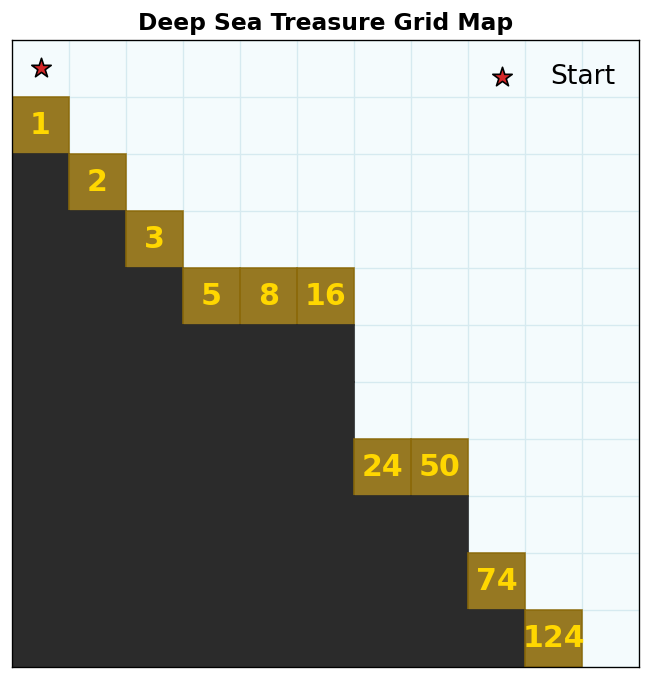

In [4]:
ENV_ID = "deep-sea-treasure-concave-v0"   # or "deep-sea-treasure-v0"
env = mo_gym.make(ENV_ID)
model = build_dst_tabular_model(env)

P = model["P"]
R = model["R"]
rho0 = model["rho0"]
S = model["S"]
A = model["A"]


gamma = 0.999
tau = 1.5 #3.
pi_ref = make_equispace_pi_ref(S, A)


plot_dst_grid(model)

In [5]:
#  D. SURF refinement in policy space
# souping policyinitialization
def policy_from_mu(mu, pi_ref, d_eps=1e-12, tiny=1e-32):
    """
    Recover a tabular policy from an occupancy measure.
    For states with tiny discounted visitation, fall back to pi_ref.
    """
    mu = np.asarray(mu, dtype=np.float64)
    pi_ref = np.asarray(pi_ref, dtype=np.float64)

    d = mu.sum(axis=1)  # (S,)
    pi = np.array(pi_ref, copy=True)

    active = d > d_eps
    pi[active] = mu[active] / d[active, None]

    # numerical safeguard
    pi = np.clip(pi, tiny, 1.0)
    pi = pi / pi.sum(axis=1, keepdims=True)

    return pi, d


def logits_from_policy(pi, tiny=1e-32):
    """
    Convert policy to logits. Since softmax is shift-invariant,
    log(pi) is a valid canonical choice.
    """
    pi = np.asarray(pi, dtype=np.float64)
    pi = np.clip(pi, tiny, 1.0)
    logits = np.log(pi)
    # optional centering for numerical stability
    logits = logits - logits.mean(axis=1, keepdims=True)
    return logits
    

def solve_cdf_refinement_policy(
    N_points,
    P,
    R,
    rho0,
    gamma,
    tau,
    pi_ref,
    max_outer_iters=10,
    alpha=0.8,
    inner_maxiter=300,
    inner_lr=0.02,
    inner_tol=1e-8,
    logits0=None,
    logits1=None,
    mu0=None,
    mu1=None,
    d_eps=1e-12,
    init_from_prev=True,
    device=DEVICE,
    verbose=False,
):
    run_start_wall = datetime.now()
    run_start_time = time.time()

    if verbose:
        print("=" * 80)
        print(f"SURF CDF refinement started at {run_start_wall.strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"N_points={N_points}, max_outer_iters={max_outer_iters}, inner_maxiter={inner_maxiter}")
        print("=" * 80)

    quantiles = np.linspace(0.0, 1.0, N_points)
    fine_w = np.linspace(0.0, 1.0, 2001)
    F_vals = fine_w.copy()
    F_history = [F_vals.copy()]

    S, A = pi_ref.shape

    current_logits = [None for _ in range(N_points)]

    if mu0 is not None and mu1 is not None:
        mu0 = np.asarray(mu0, dtype=np.float64)
        mu1 = np.asarray(mu1, dtype=np.float64)

        for i, q in enumerate(quantiles):
            mu_q = (1.0 - q) * mu0 + q * mu1
            mu_q = np.maximum(mu_q, 0.0)

            pi_q, _ = policy_from_mu(mu_q, pi_ref, d_eps=d_eps)
            current_logits[i] = logits_from_policy(pi_q)

    elif logits0 is not None and logits1 is not None:
        current_logits = [
            (1.0 - q) * logits0 + q * logits1 for q in quantiles
        ]

    pf_history = []
    pf_history_raw = []
    policy_history = []
    weight_history = []
    time_history = []

    for t in range(max_outer_iters):
        outer_start_wall = datetime.now()
        outer_start_time = time.time()

        current_w = np.interp(quantiles, F_vals, fine_w)
        weight_history.append(current_w.copy())

        if verbose:
            print(f"\n--- Outer iteration {t} ---")
            print(f"start time: {outer_start_wall.strftime('%Y-%m-%d %H:%M:%S')}")
            print("weights:", np.round(current_w, 4))

        results_t = []
        f_coords = []
        inner_time_history = []

        for n, w in enumerate(current_w):
            inner_start_wall = datetime.now()
            inner_start_time = time.time()

            if verbose:
                print(
                    f"  [{inner_start_wall.strftime('%H:%M:%S')}] "
                    f"solving point {n + 1}/{N_points}, w={w:.6f}"
                )

            if init_from_prev and current_logits[n] is not None:
                logits_init = current_logits[n]
            elif logits0 is not None and logits1 is not None:
                logits_init = (1.0 - w) * logits0 + w * logits1
            else:
                logits_init = np.zeros((S, A), dtype=np.float32)

            sol = solve_policy_scalarization(
                w=w,
                P=P,
                R=R,
                rho0=rho0,
                gamma=gamma,
                tau=tau,
                pi_ref=pi_ref,
                logits_init=logits_init,
                lr=inner_lr,
                maxiter=inner_maxiter,
                tol=inner_tol,
                device=device,
                verbose=False,
            )

            inner_end_wall = datetime.now()
            inner_elapsed = time.time() - inner_start_time

            if verbose:
                print(
                    f"  [{inner_end_wall.strftime('%H:%M:%S')}] "
                    f"finished point {n + 1}/{N_points}, "
                    f"elapsed={inner_elapsed:.2f}s, "
                    f"R1={sol['R1']:.6f}, R2={sol['R2']:.6f}"
                )

            inner_time_history.append({
                "outer_iter": t,
                "point_index": n,
                "weight": float(w),
                "start_time": inner_start_wall.strftime("%Y-%m-%d %H:%M:%S"),
                "end_time": inner_end_wall.strftime("%Y-%m-%d %H:%M:%S"),
                "elapsed_sec": float(inner_elapsed),
            })

            current_logits[n] = sol["logits"]
            results_t.append(sol)
            f_coords.append([sol["R1"], sol["R2"]])

        f_coords = np.asarray(f_coords, dtype=np.float32)

        pf_history.append(f_coords)
        policy_history.append(results_t)

        diffs = np.diff(f_coords, axis=0)
        seg_lens = np.sqrt(np.sum(diffs ** 2, axis=1))
        s_vals = np.concatenate([[0.0], np.cumsum(seg_lens)])
        total_len = s_vals[-1]

        if total_len <= 1e-14:
            outer_end_wall = datetime.now()
            outer_elapsed = time.time() - outer_start_time

            time_history.append({
                "outer_iter": t,
                "start_time": outer_start_wall.strftime("%Y-%m-%d %H:%M:%S"),
                "end_time": outer_end_wall.strftime("%Y-%m-%d %H:%M:%S"),
                "elapsed_sec": float(outer_elapsed),
                "total_pf_length": float(total_len),
                "inner_times": inner_time_history,
                "stopped": True,
            })

            if verbose:
                print("PF length is zero. Stopping.")
                print(f"outer elapsed = {outer_elapsed:.2f}s")

            break

        tilde_F_values = s_vals / total_len

        interp_tilde_F = PchipInterpolator(current_w, tilde_F_values)
        tilde_vals = interp_tilde_F(fine_w)

        F_vals = (1.0 - alpha) * F_vals + alpha * tilde_vals

        F_vals = np.maximum.accumulate(F_vals)
        F_vals[0] = 0.0
        F_vals[-1] = 1.0

        F_history.append(F_vals.copy())

        outer_end_wall = datetime.now()
        outer_elapsed = time.time() - outer_start_time
        total_elapsed = time.time() - run_start_time

        time_history.append({
            "outer_iter": t,
            "start_time": outer_start_wall.strftime("%Y-%m-%d %H:%M:%S"),
            "end_time": outer_end_wall.strftime("%Y-%m-%d %H:%M:%S"),
            "elapsed_sec": float(outer_elapsed),
            "total_elapsed_sec": float(total_elapsed),
            "total_pf_length": float(total_len),
            "inner_times": inner_time_history,
            "stopped": False,
        })

        if verbose:
            print(f"total PF length = {total_len:.6f}")
            print(f"outer elapsed = {outer_elapsed:.2f}s")
            print(f"total elapsed = {total_elapsed:.2f}s")
            print(f"finished at: {outer_end_wall.strftime('%Y-%m-%d %H:%M:%S')}")

    final_w = np.interp(quantiles, F_vals, fine_w)

    run_end_wall = datetime.now()
    run_elapsed = time.time() - run_start_time

    if verbose:
        print("=" * 80)
        print(f"SURF CDF refinement finished at {run_end_wall.strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"total runtime = {run_elapsed:.2f}s")
        print("=" * 80)

    return {
        "final_w": final_w,
        "final_logits": current_logits,
        "pf_history": pf_history,
        "policy_history": policy_history,
        "weight_history": weight_history,
        "F_history": F_history,
        "F_grid_w": fine_w,
        "F_grid_vals": F_vals,
        "time_history": time_history,
        "run_start_time": run_start_wall.strftime("%Y-%m-%d %H:%M:%S"),
        "run_end_time": run_end_wall.strftime("%Y-%m-%d %H:%M:%S"),
        "run_elapsed_sec": float(run_elapsed),
    }

### Baselines

In [6]:
def run_ols_policy_baseline(
    N_points,
    P, R, rho0, gamma, tau, pi_ref,
    inner_maxiter=300,
    inner_lr=0.02,
    inner_tol=1e-8,
    epsilon_ols=1e-6,
    logits0=None,
    logits1=None,
    init_mode="interp",   # "interp", "prev", or "zero"
    duplicate_tol=1e-6,
    max_total_queries=None,   # optional cap on total oracle calls
    device=DEVICE,
    verbose=True,
):
    """
    MORL-Baselines OLS outer loop + your exact scalarized policy solver.

    Keeps only distinct solutions in objective space.
    A solution is considered duplicate if [R1, R2, reg] is too close
    to a previously accepted one.
    """

    run_start_wall = datetime.now()
    run_start_time = time.time()

    if verbose:
        print("=" * 80)
        print(f"OLS baseline started at {run_start_wall.strftime('%Y-%m-%d %H:%M:%S')}")
        print(
            f"N_points={N_points}, inner_maxiter={inner_maxiter}, "
            f"epsilon_ols={epsilon_ols}, init_mode={init_mode}"
        )
        print("=" * 80)

    ols = LinearSupport(num_objectives=2, epsilon=epsilon_ols, verbose=verbose)

    accepted_results = []
    accepted_weight_vecs = []
    prev_logits = None
    num_queries = 0
    time_history = []

    if max_total_queries is None:
        max_total_queries = max(10 * N_points, 30)

    def is_duplicate_solution(sol, accepted, tol=duplicate_tol):
        p = np.array([sol["R1"], sol["R2"], sol["reg"]], dtype=np.float64)
        for old in accepted:
            q = np.array([old["R1"], old["R2"], old["reg"]], dtype=np.float64)
            if np.linalg.norm(p - q, ord=2) < tol:
                return True
        return False

    while len(accepted_results) < N_points and num_queries < max_total_queries:
        query_start_wall = datetime.now()
        query_start_time = time.time()

        w_vec = ols.next_weight(algo="ols")
        if w_vec is None:
            if verbose:
                print(
                    f"[{datetime.now().strftime('%H:%M:%S')}] "
                    "[OLS] next_weight returned None; stopping."
                )
            break

        w_vec = np.asarray(w_vec, dtype=np.float64)
        assert w_vec.shape == (2,), f"Expected 2D weight vector, got {w_vec.shape}"
        assert w_vec.sum() > 0, "OLS returned a nonpositive weight vector sum"
        w_vec = w_vec / w_vec.sum()
        w = float(w_vec[1])

        if verbose:
            print(
                f"\n[{query_start_wall.strftime('%Y-%m-%d %H:%M:%S')}] "
                f"OLS query #{num_queries + 1:02d} started, w={w:.6f}"
            )

        if init_mode == "interp" and logits0 is not None and logits1 is not None:
            logits_init = (1.0 - w) * logits0 + w * logits1
        elif init_mode == "prev" and prev_logits is not None:
            logits_init = prev_logits
        else:
            logits_init = None

        sol = solve_policy_scalarization(
            w=w,
            P=P,
            R=R,
            rho0=rho0,
            gamma=gamma,
            tau=tau,
            pi_ref=pi_ref,
            logits_init=logits_init,
            lr=inner_lr,
            maxiter=inner_maxiter,
            tol=inner_tol,
            device=device,
            verbose=False,
        )
        num_queries += 1

        value = np.array(
            [sol["R1"] - sol["reg"], sol["R2"] - sol["reg"]],
            dtype=np.float64
        )

        ols.add_solution(value=value, w=w_vec)

        dup = is_duplicate_solution(sol, accepted_results, tol=duplicate_tol)

        if not dup:
            accepted_results.append(sol)
            accepted_weight_vecs.append(w_vec)
            if hasattr(sol["logits"], "detach"):
                prev_logits = sol["logits"].detach().clone()
            else:
                prev_logits = sol["logits"]

        query_end_wall = datetime.now()
        query_elapsed = time.time() - query_start_time
        total_elapsed = time.time() - run_start_time

        query_time_info = {
            "query": int(num_queries),
            "start_time": query_start_wall.strftime("%Y-%m-%d %H:%M:%S"),
            "end_time": query_end_wall.strftime("%Y-%m-%d %H:%M:%S"),
            "elapsed_sec": float(query_elapsed),
            "total_elapsed_sec": float(total_elapsed),
            "w": float(w),
            "weight_vec": w_vec.copy(),
            "value": value.copy(),
            "R1": float(sol["R1"]),
            "R2": float(sol["R2"]),
            "reg": float(sol["reg"]),
            "duplicate": bool(dup),
            "num_accepted": int(len(accepted_results)),
        }
        time_history.append(query_time_info)

        if verbose:
            msg = (
                f"[{query_end_wall.strftime('%H:%M:%S')}] "
                f"[OLS] query #{num_queries:02d} finished  "
                f"elapsed={query_elapsed:.2f}s  "
                f"total_elapsed={total_elapsed:.2f}s  "
                f"accepted={len(accepted_results)}/{N_points}  "
                f"w={w:.6f}  "
                f"value=[{value[0]:.8f}, {value[1]:.8f}]  "
                f"raw=[{sol['R1']:.8f}, {sol['R2']:.8f}]  "
                f"reg={sol['reg']:.8f}"
            )
            if dup:
                msg += "  --> duplicate, skipped"
            print(msg)

        if ols.ended():
            if verbose:
                print(
                    f"[{datetime.now().strftime('%H:%M:%S')}] "
                    "[OLS] ended() is True; stopping."
                )
            break

    run_end_wall = datetime.now()
    run_elapsed = time.time() - run_start_time

    if verbose:
        print("=" * 80)
        print(f"OLS baseline finished at {run_end_wall.strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"accepted={len(accepted_results)}/{N_points}, queries={num_queries}")
        print(f"total runtime = {run_elapsed:.2f}s")
        print("=" * 80)

    if len(accepted_results) == 0:
        return {
            "weights": np.zeros((0, 2)),
            "scalar_weights": np.zeros((0,)),
            "results": [],
            "pf": np.zeros((0, 2)),
            "pf_reward": np.zeros((0, 2)),
            "pf_reg_reward": np.zeros((0, 2)),
            "pf_cost": np.zeros((0, 2)),
            "num_queries": num_queries,
            "ols": ols,
            "time_history": time_history,
            "run_start_time": run_start_wall.strftime("%Y-%m-%d %H:%M:%S"),
            "run_end_time": run_end_wall.strftime("%Y-%m-%d %H:%M:%S"),
            "run_elapsed_sec": float(run_elapsed),
        }

    scalar_ws = np.array([wv[1] for wv in accepted_weight_vecs], dtype=np.float64)
    order = np.argsort(scalar_ws)

    accepted_results = [accepted_results[i] for i in order]
    accepted_weight_vecs = np.array(accepted_weight_vecs, dtype=np.float64)[order]
    scalar_ws = scalar_ws[order]

    pf_reward = np.array(
        [[r["R1"], r["R2"]] for r in accepted_results],
        dtype=np.float64
    )

    pf_reg_reward = np.array(
        [[r["R1"] - r["reg"], r["R2"] - r["reg"]] for r in accepted_results],
        dtype=np.float64
    )

    pf_cost = np.array(
        [[-r["R1"] + r["reg"], -r["R2"] + r["reg"]] for r in accepted_results],
        dtype=np.float64
    )

    return {
        "weights": accepted_weight_vecs,
        "scalar_weights": scalar_ws,
        "results": accepted_results,
        "pf": pf_reg_reward,
        "pf_reward": pf_reward,
        "pf_reg_reward": pf_reg_reward,
        "pf_cost": pf_cost,
        "num_queries": num_queries,
        "ols": ols,

        # Timing information.
        "time_history": time_history,
        "run_start_time": run_start_wall.strftime("%Y-%m-%d %H:%M:%S"),
        "run_end_time": run_end_wall.strftime("%Y-%m-%d %H:%M:%S"),
        "run_elapsed_sec": float(run_elapsed),
    }

In [7]:
#  E. Baselines with the same inner policy optimizer
def run_equispace_weights_policy_baseline(
    N_points,
    P, R, rho0, gamma, tau, pi_ref,
    inner_maxiter=300,
    inner_lr=0.02,
    inner_tol=1e-8,
    logits0=None,
    logits1=None,
    device=DEVICE,
    verbose=True,
):
    run_start_wall = datetime.now()
    run_start_time = time.time()

    if verbose:
        print("=" * 80)
        print(f"Equispaced LS baseline started at {run_start_wall.strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"N_points={N_points}, inner_maxiter={inner_maxiter}, inner_lr={inner_lr}")
        print("=" * 80)

    weights = np.linspace(0.0, 1.0, N_points)
    results = []
    prev_logits = None
    time_history = []

    for k, w in enumerate(weights):
        query_start_wall = datetime.now()
        query_start_time = time.time()

        if verbose:
            print(
                f"\n[{query_start_wall.strftime('%Y-%m-%d %H:%M:%S')}] "
                f"Equispaced LS point {k + 1}/{N_points} started, w={w:.6f}"
            )

        logits_init = prev_logits
        if logits_init is None:
            if logits0 is not None and logits1 is not None:
                logits_init = (1.0 - w) * logits0 + w * logits1

        sol = solve_policy_scalarization(
            w=w,
            P=P,
            R=R,
            rho0=rho0,
            gamma=gamma,
            tau=tau,
            pi_ref=pi_ref,
            logits_init=logits_init,
            lr=inner_lr,
            maxiter=inner_maxiter,
            tol=inner_tol,
            device=device,
        )

        results.append(sol)
        prev_logits = sol["logits"]

        query_end_wall = datetime.now()
        query_elapsed = time.time() - query_start_time
        total_elapsed = time.time() - run_start_time

        query_time_info = {
            "point_index": int(k),
            "w": float(w),
            "start_time": query_start_wall.strftime("%Y-%m-%d %H:%M:%S"),
            "end_time": query_end_wall.strftime("%Y-%m-%d %H:%M:%S"),
            "elapsed_sec": float(query_elapsed),
            "total_elapsed_sec": float(total_elapsed),
            "R1": float(sol["R1"]),
            "R2": float(sol["R2"]),
            "reg": float(sol["reg"]),
        }
        time_history.append(query_time_info)

        if verbose:
            print(
                f"[{query_end_wall.strftime('%H:%M:%S')}] "
                f"finished point {k + 1}/{N_points}, "
                f"elapsed={query_elapsed:.2f}s, "
                f"total_elapsed={total_elapsed:.2f}s, "
                f"R1={sol['R1']:.6f}, R2={sol['R2']:.6f}, reg={sol['reg']:.6f}"
            )

    pf = np.array([[r["R1"], r["R2"]] for r in results], dtype=np.float32)

    run_end_wall = datetime.now()
    run_elapsed = time.time() - run_start_time

    if verbose:
        print("=" * 80)
        print(f"Equispaced LS baseline finished at {run_end_wall.strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"total runtime = {run_elapsed:.2f}s")
        print("=" * 80)

    return {
        "weights": weights,
        "results": results,
        "pf": pf,
        "time_history": time_history,
        "run_start_time": run_start_wall.strftime("%Y-%m-%d %H:%M:%S"),
        "run_end_time": run_end_wall.strftime("%Y-%m-%d %H:%M:%S"),
        "run_elapsed_sec": float(run_elapsed),
    }
def run_soup_weights_policy_baseline(
    N_points,
    P, R, rho0, gamma, tau, pi_ref,
    logits0,
    logits1,
    device=DEVICE,
):
    weights = np.linspace(0.0, 1.0, N_points)
    results = []

    P_t = torch.tensor(P, dtype=torch.float32, device=DEVICE)
    R_t = torch.tensor(R, dtype=torch.float32, device=DEVICE)
    rho0_t = torch.tensor(rho0, dtype=torch.float32, device=DEVICE)
    pi_ref_t = torch.tensor(pi_ref, dtype=torch.float32, device=DEVICE)

    for w in weights:
        logits_soup = (1.0 - w) * logits0 + w * logits1
        # logits_soup = softmax(logits_soup, axis=-1)
        logits_t = torch.tensor(logits_soup, dtype=torch.float32, device=DEVICE)

        out = evaluate_policy_torch(
            logits_t, P_t, R_t, rho0_t, gamma, tau, pi_ref_t
        )

        results.append({
            "w": float(w),
            "logits": logits_soup,
            "pi": out["pi"].detach().cpu().numpy(),
            "d": out["d"].detach().cpu().numpy(),
            "mu": out["mu"].detach().cpu().numpy(),
            "R1": float(out["R1"].detach().cpu().item()),
            "R2": float(out["R2"].detach().cpu().item()),
            "reg": float(out["reg"].detach().cpu().item()),
        })

    pf = np.array([[r["R1"], r["R2"]] for r in results], dtype=np.float32)
    return {"weights": weights, "results": results, "pf": pf}

def run_soup_weights_measure_baseline(
    N_points,
    R, tau, pi_ref,
    mu0,
    mu1,
    d_eps=1e-12,
):
    """
    Soup in occupancy-measure space:
        mu_soup = (1-w) * mu0 + w * mu1

    Then recover a policy by
        pi(a|s) = mu(s,a) / sum_a mu(s,a)
    on active states, and use pi_ref on nearly inactive states.

    Returns the same structure:
        {"weights": weights, "results": results, "pf": pf}
    """
    weights = np.linspace(0.0, 1.0, N_points)
    results = []

    R = np.asarray(R, dtype=np.float64)
    pi_ref = np.asarray(pi_ref, dtype=np.float64)
    mu0 = np.asarray(mu0, dtype=np.float64)
    mu1 = np.asarray(mu1, dtype=np.float64)

    tiny = 1e-32

    for w in weights:
        # 1) soup in measure space
        mu = (1.0 - w) * mu0 + w * mu1

        # numerical safeguard
        mu = np.maximum(mu, 0.0)

        # 2) recover discounted state marginals
        d = mu.sum(axis=1)   # shape: (S,)

        # 3) recover policy safely
        pi = np.array(pi_ref, copy=True)
        active = d > d_eps
        pi[active] = mu[active] / d[active, None]

        # optional renormalization for safety
        row_sums = pi.sum(axis=1, keepdims=True)
        bad = row_sums.squeeze(-1) <= 0
        pi[~bad] = pi[~bad] / row_sums[~bad]
        pi[bad] = pi_ref[bad]

        # 4) compute objectives from mu directly
        R1 = float(np.sum(mu * R[..., 0]))
        R2 = float(np.sum(mu * R[..., 1]))

        # 5) regularizer from (mu, pi)
        # matches KL-style state-action regularization:
        #   reg = tau * sum_{s,a} mu(s,a) [log pi(a|s) - log pi_ref(a|s)]
        log_pi = np.log(np.clip(pi, tiny, 1.0))
        log_pi_ref = np.log(np.clip(pi_ref, tiny, 1.0))
        reg = float(tau * np.sum(mu * (log_pi - log_pi_ref)))

        results.append({
            "w": float(w),
            "pi": pi,
            "d": d,
            "mu": mu,
            "R1": R1,
            "R2": R2,
            "reg": reg,
        })

    pf = np.array([[r["R1"], r["R2"]] for r in results], dtype=np.float32)
    return {"weights": weights, "results": results, "pf": pf}
    

In [8]:
def pack_umod_solution_points(results):
    """
    Standardize UMOD objective bookkeeping.

    Default PF convention:
        pf = pf_reg_reward = [R1 - reg, R2 - reg]

    Also keep:
        pf_reward = [R1, R2]
        pf_cost   = [-R1 + reg, -R2 + reg]
    """
    pf_reward = []
    pf_reg_reward = []
    pf_cost = []

    for sol in results:
        raw = np.array([sol["R1"], sol["R2"]], dtype=np.float64)
        reg = float(sol["reg"])

        pf_reward.append(raw)
        pf_reg_reward.append(raw - reg)
        pf_cost.append(-raw + reg)

    pf_reward = np.asarray(pf_reward, dtype=np.float64)
    pf_reg_reward = np.asarray(pf_reg_reward, dtype=np.float64)
    pf_cost = np.asarray(pf_cost, dtype=np.float64)

    return {
        "pf_reward": pf_reward,
        "pf_reg_reward": pf_reg_reward,
        "pf_cost": pf_cost,
        "pf": pf_reg_reward,   # important: default PF is always R - reg
    }

def project_theta_biobj(theta, eps=1e-4):
    """
    Keep endpoints fixed and prevent interior angles from collapsing
    onto endpoints or crossing each other.
    """
    K = len(theta)
    theta = np.asarray(theta, dtype=np.float64)

    theta[0] = 0.0
    theta[-1] = 0.5 * np.pi

    if K > 2:
        interior = np.sort(theta[1:-1])
        lo = eps
        hi = 0.5 * np.pi - eps

        # Enforce strict spacing in angle space.
        grid_lo = np.linspace(lo, hi, K)[1:-1]
        interior = np.maximum(interior, grid_lo * 0.0 + lo)
        interior = np.minimum(interior, hi)

        # Minimum separation between neighboring angles.
        min_sep = eps
        for k in range(1, len(interior)):
            interior[k] = max(interior[k], interior[k - 1] + min_sep)

        # If the right side exceeds the boundary, push backward.
        if len(interior) > 0 and interior[-1] > hi:
            interior[-1] = hi
            for k in range(len(interior) - 2, -1, -1):
                interior[k] = min(interior[k], interior[k + 1] - min_sep)

        theta[1:-1] = interior

    return theta

In [9]:
# ============================================================
# Faithful UMOD for the bi-objective policy setting
#   - preference-angle parameterization
#   - modified Tchebycheff inner oracle
#   - PF surrogate h_phi(theta) -> y
#   - Algorithm 2 closest-pair angle update
#   - fixed K points
#   - warm start from previous outer iteration
#   - default PF convention: [R1 - reg, R2 - reg]
# ============================================================


def pack_umod_solution_points(results):
    """
    Standard UMOD objective bookkeeping.

    Default PF convention:
        pf = pf_reg_reward = [R1 - reg, R2 - reg]

    Also store:
        pf_reward = [R1, R2]
        pf_cost   = [-R1 + reg, -R2 + reg]
    """
    pf_reward = []
    pf_reg_reward = []
    pf_cost = []

    for sol in results:
        raw = np.array([sol["R1"], sol["R2"]], dtype=np.float64)
        reg = float(sol.get("reg", 0.0))

        pf_reward.append(raw)
        pf_reg_reward.append(raw - reg)
        pf_cost.append(-raw + reg)

    pf_reward = np.asarray(pf_reward, dtype=np.float64)
    pf_reg_reward = np.asarray(pf_reg_reward, dtype=np.float64)
    pf_cost = np.asarray(pf_cost, dtype=np.float64)

    return {
        "pf_reward": pf_reward,
        "pf_reg_reward": pf_reg_reward,
        "pf_cost": pf_cost,
        "pf": pf_reg_reward,   # important: default PF is always R - reg
    }


def project_theta_biobj(theta_vals, eps=1e-3):
    """
    Keep endpoints fixed and prevent interior angles from collapsing
    onto endpoints or crossing each other.

    eps is an angle-space separation. If GapRatio is still unstable,
    try eps=5e-3 or eps=1e-2.
    """
    theta_vals = np.asarray(theta_vals, dtype=np.float64).copy()
    K = len(theta_vals)

    if K == 0:
        return theta_vals

    if K == 1:
        theta_vals[0] = 0.0
        return theta_vals

    lower = 0.0
    upper = 0.5 * np.pi

    theta_vals[0] = lower
    theta_vals[-1] = upper

    if K <= 2:
        return theta_vals

    interior = np.sort(theta_vals[1:-1])

    lo = lower + eps
    hi = upper - eps
    min_sep = eps

    interior = np.clip(interior, lo, hi)

    # Forward pass: enforce increasing separation.
    for i in range(1, len(interior)):
        interior[i] = max(interior[i], interior[i - 1] + min_sep)

    # Backward pass if the right side exceeds the upper boundary.
    if len(interior) > 0 and interior[-1] > hi:
        interior[-1] = hi
        for i in range(len(interior) - 2, -1, -1):
            interior[i] = min(interior[i], interior[i + 1] - min_sep)

    interior = np.clip(interior, lo, hi)
    theta_vals[1:-1] = interior

    return theta_vals


# -------------------------------
# 1) PF surrogate h_phi(theta) -> y
# -------------------------------

class UMODPFModel(nn.Module):
    def __init__(self, hidden_dim=128, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, theta):
        if theta.ndim == 1:
            theta = theta[:, None]
        return self.net(theta)


# -------------------------------
# 2) Preference angle <-> preference vector
#    Bi-objective case:
#       lambda_1 = cos^2(theta)
#       lambda_2 = sin^2(theta)
#       theta in [0, pi/2]
# -------------------------------

def theta_to_lambda_biobj(theta_vals, eps=1e-6):
    theta_vals = np.asarray(theta_vals, dtype=np.float64)

    lam1 = np.cos(theta_vals) ** 2
    lam2 = np.sin(theta_vals) ** 2
    lam = np.stack([lam1, lam2], axis=-1)

    lam = np.clip(lam, eps, None)
    lam /= np.sum(lam, axis=-1, keepdims=True)
    return lam


def lambda_to_theta_biobj(lambda_vals):
    lambda_vals = np.asarray(lambda_vals, dtype=np.float64)
    lam1 = np.clip(lambda_vals[..., 0], 0.0, 1.0)
    return np.arccos(np.sqrt(lam1))


def das_dennis_biobj(K):
    """
    Bi-objective Das-Dennis initialization on the simplex.
    """
    t = np.linspace(0.0, 1.0, K, dtype=np.float64)
    lam = np.stack([1.0 - t, t], axis=1)
    return lam


# -------------------------------
# 3) Policy evaluation from logits
# -------------------------------

def evaluate_policy_from_logits(
    logits,
    P,
    R,
    rho0,
    gamma,
    tau,
    pi_ref,
    device=None,
):
    """
    Evaluate a stationary softmax policy.

    Uses normalized discounted occupancy:
        sum_{s,a} mu(s,a) = 1

    Returns raw rewards R1, R2 and regularizer reg.

    Convention:
        regularized reward coordinates:
            [R1 - reg, R2 - reg]

        regularized cost coordinates:
            [-R1 + reg, -R2 + reg]
    """
    if device is None:
        device = DEVICE

    P_t = torch.tensor(P, dtype=torch.float32, device=device)
    R_t = torch.tensor(R, dtype=torch.float32, device=device)
    rho0_t = torch.tensor(rho0, dtype=torch.float32, device=device)
    pi_ref_t = torch.tensor(pi_ref, dtype=torch.float32, device=device).clamp_min(1e-12)

    if torch.is_tensor(logits):
        logits_t = logits.to(dtype=torch.float32, device=device)
    else:
        logits_t = torch.tensor(logits, dtype=torch.float32, device=device)

    pi = torch.softmax(logits_t, dim=-1).clamp_min(1e-12)

    S, A = pi.shape

    # P_pi[s, s'] = sum_a pi(a|s) P(s'|s,a)
    P_pi = torch.einsum("sa,san->sn", pi, P_t)

    I = torch.eye(S, dtype=torch.float32, device=device)

    # Normalized discounted state visitation.
    # This is the key scale convention:
    #     sum_s d(s) = 1
    d = torch.linalg.solve(I - gamma * P_pi.T, (1.0 - gamma) * rho0_t)

    mu = d[:, None] * pi

    R1 = torch.sum(mu * R_t[:, :, 0])
    R2 = torch.sum(mu * R_t[:, :, 1])

    kl_sa = pi * (torch.log(pi) - torch.log(pi_ref_t))
    reg = tau * torch.sum(d * torch.sum(kl_sa, dim=-1))

    return {
        "logits": logits_t,
        "pi": pi,
        "d": d,
        "mu": mu,
        "R1": R1,
        "R2": R2,
        "reg": reg,
    }


def detach_policy_eval(eval_dict):
    return {
        "logits": eval_dict["logits"].detach().cpu().numpy(),
        "pi": eval_dict["pi"].detach().cpu().numpy(),
        "d": eval_dict["d"].detach().cpu().numpy(),
        "mu": eval_dict["mu"].detach().cpu().numpy(),
        "R1": float(eval_dict["R1"].detach().cpu()),
        "R2": float(eval_dict["R2"].detach().cpu()),
        "reg": float(eval_dict["reg"].detach().cpu()),
    }


# -------------------------------
# 4) Modified Tchebycheff inner oracle
# -------------------------------

def solve_policy_mtche_lambda(
    lambda_vec,
    P,
    R,
    rho0,
    gamma,
    tau,
    pi_ref,
    z_ref,
    logits_init=None,
    lr=0.01,
    maxiter=300,
    tol=1e-8,
    device=None,
    verbose=False,
    smooth_tau=0.01,
):
    """
    Faithful UMOD inner oracle.

    UMOD uses modified Tchebycheff, not linear scalarization.

    Reward maximization:
        J(pi) = [R1(pi), R2(pi)]

    Convert to regularized costs:
        c1 = -R1 + reg
        c2 = -R2 + reg

    mTche objective:
        min_pi max_i (c_i(pi) - z_i) / lambda_i
    """
    if device is None:
        device = DEVICE

    lambda_vec = np.asarray(lambda_vec, dtype=np.float64)
    lambda_vec = np.clip(lambda_vec, 1e-6, None)
    lambda_vec = lambda_vec / np.sum(lambda_vec)

    if lambda_vec.shape != (2,):
        raise ValueError(f"Expected lambda_vec with shape (2,), got {lambda_vec.shape}")

    z_ref = np.asarray(z_ref, dtype=np.float64)
    if z_ref.shape != (2,):
        raise ValueError(f"Expected z_ref with shape (2,), got {z_ref.shape}")

    P_arr = np.asarray(P)
    S, A = P_arr.shape[0], P_arr.shape[1]

    if logits_init is None:
        logits = torch.zeros((S, A), dtype=torch.float32, device=device, requires_grad=True)
    else:
        logits = torch.tensor(logits_init, dtype=torch.float32, device=device, requires_grad=True)

    lam_t = torch.tensor(lambda_vec, dtype=torch.float32, device=device)
    z_t = torch.tensor(z_ref, dtype=torch.float32, device=device)

    opt = torch.optim.Adam([logits], lr=lr)

    last_loss = None

    for it in range(maxiter):
        eval_dict = evaluate_policy_from_logits(
            logits=logits,
            P=P,
            R=R,
            rho0=rho0,
            gamma=gamma,
            tau=tau,
            pi_ref=pi_ref,
            device=device,
        )

        R1 = eval_dict["R1"]
        R2 = eval_dict["R2"]
        reg = eval_dict["reg"]

        cost = torch.stack([
            -R1 + reg,
            -R2 + reg,
        ])

        scaled = (cost - z_t) / lam_t

        if smooth_tau is None or smooth_tau <= 0:
            loss = torch.max(scaled)
        else:
            loss = smooth_tau * torch.logsumexp(scaled / smooth_tau, dim=0)

        opt.zero_grad()
        loss.backward()
        opt.step()

        loss_val = float(loss.detach().cpu())

        if verbose and it % 30 == 0:
            print(f"[mTche] iter={it:04d} loss={loss_val:.8e}")

        if last_loss is not None and abs(last_loss - loss_val) < tol:
            break

        last_loss = loss_val

    final_eval = evaluate_policy_from_logits(
        logits=logits,
        P=P,
        R=R,
        rho0=rho0,
        gamma=gamma,
        tau=tau,
        pi_ref=pi_ref,
        device=device,
    )

    out = detach_policy_eval(final_eval)

    R1 = out["R1"]
    R2 = out["R2"]
    reg = out["reg"]

    cost = np.array([-R1 + reg, -R2 + reg], dtype=np.float64)
    scaled = (cost - z_ref) / lambda_vec

    out["cost"] = cost
    out["mtche_value"] = float(np.max(scaled))
    out["objective"] = -out["mtche_value"]
    out["loss"] = out["mtche_value"]

    return out


# -------------------------------
# 5) Reference point for mTche
# -------------------------------

def estimate_mtche_reference_from_results(results, margin=1e-3):
    """
    Estimate z in cost space.

    For regularized costs:
        c = [-R1 + reg, -R2 + reg]

    z should be slightly better than observed costs componentwise.
    """
    cost = np.asarray([
        [-sol["R1"] + sol["reg"], -sol["R2"] + sol["reg"]]
        for sol in results
    ], dtype=np.float64)

    return cost.min(axis=0) - margin


def evaluate_logits_bank_for_reference(
    logits_bank,
    P,
    R,
    rho0,
    gamma,
    tau,
    pi_ref,
    device=None,
):
    results = []

    for logits in logits_bank:
        if logits is None:
            P_arr = np.asarray(P)
            S, A = P_arr.shape[0], P_arr.shape[1]
            logits = np.zeros((S, A), dtype=np.float32)

        eval_dict = evaluate_policy_from_logits(
            logits=logits,
            P=P,
            R=R,
            rho0=rho0,
            gamma=gamma,
            tau=tau,
            pi_ref=pi_ref,
            device=device,
        )
        results.append(detach_policy_eval(eval_dict))

    return results


# -------------------------------
# 6) Train h_phi by MSE on (theta, y)
# -------------------------------

def fit_pf_model(
    theta_vals,
    pf_vals,
    hidden_dim=128,
    epochs=1000,
    lr=1e-3,
    device="cpu",
):
    model = UMODPFModel(hidden_dim=hidden_dim, out_dim=pf_vals.shape[1]).to(device)

    x = torch.tensor(theta_vals, dtype=torch.float32, device=device)[:, None]
    y = torch.tensor(pf_vals, dtype=torch.float32, device=device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for _ in range(epochs):
        pred = model(x)
        loss = ((pred - y) ** 2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

    return model


# -------------------------------
# 7) Algorithm 2: Recalculate preference angles
# -------------------------------

def alg_update_biobj(
    theta_vals,
    model,
    Nopt=200,
    eta=1e-2,
    device="cpu",
    fix_endpoints=True,
    theta_eps=1e-3,
):
    """
    Bi-objective UMOD angle update.

    Repeatedly:
      1. predict PF points h_phi(theta_k)
      2. find closest pair
      3. move the non-fixed members of that pair to increase distance
      4. project theta so endpoints stay fixed and interior points do not collapse
    """
    theta_vals = project_theta_biobj(theta_vals, eps=theta_eps)

    theta = torch.tensor(theta_vals, dtype=torch.float32, device=device)

    lower = 0.0
    upper = 0.5 * np.pi

    for _ in range(Nopt):
        with torch.no_grad():
            pred = model(theta[:, None])
            D = torch.cdist(pred, pred, p=2)
            K = D.shape[0]
            D.fill_diagonal_(float("inf"))

            # Do NOT mask endpoint pairs.
            # If an interior point collapses onto an endpoint, this lets us detect it.
            flat_idx = torch.argmin(D)
            i_star = int(flat_idx // K)
            j_star = int(flat_idx % K)

        ti = theta[i_star].detach().clone().requires_grad_(True)
        tj = theta[j_star].detach().clone().requires_grad_(True)

        yi = model(ti.view(1, 1)).view(-1)
        yj = model(tj.view(1, 1)).view(-1)

        rho = torch.norm(yi - yj, p=2).clamp_min(1e-12)
        direction = ((yi - yj) / rho).detach()

        grad_i = torch.autograd.grad(
            yi,
            ti,
            grad_outputs=direction,
            retain_graph=False,
            create_graph=False,
        )[0]

        grad_j = torch.autograd.grad(
            yj,
            tj,
            grad_outputs=direction,
            retain_graph=False,
            create_graph=False,
        )[0]

        with torch.no_grad():
            # Endpoints remain fixed, but endpoint-neighbor collisions are still detected.
            i_fixed = fix_endpoints and (i_star == 0 or i_star == K - 1)
            j_fixed = fix_endpoints and (j_star == 0 or j_star == K - 1)

            if not i_fixed:
                theta[i_star] = torch.clamp(theta[i_star] + eta * grad_i, lower, upper)

            if not j_fixed:
                theta[j_star] = torch.clamp(theta[j_star] - eta * grad_j, lower, upper)

            if fix_endpoints and len(theta) >= 2:
                theta_np = theta.detach().cpu().numpy()
                theta_np = project_theta_biobj(theta_np, eps=theta_eps)
                theta.copy_(torch.tensor(theta_np, dtype=theta.dtype, device=device))

    return theta.detach().cpu().numpy()


# -------------------------------
# 8) Initial logits bank
# -------------------------------

def build_initial_logits_bank_from_endpoints(lambda_vals, logits0=None, logits1=None):
    K = len(lambda_vals)

    if logits0 is None and logits1 is None:
        return [None for _ in range(K)]

    if logits0 is None or logits1 is None:
        raise ValueError("Provide both logits0 and logits1, or neither.")

    bank = []
    for lam in lambda_vals:
        w = float(lam[1])
        bank.append((1.0 - w) * logits0 + w * logits1)

    return bank


# -------------------------------
# 9) Faithful UMOD outer loop
# -------------------------------
def run_umod_policy_baseline_faithful(
    N_points,
    P,
    R,
    rho0,
    gamma,
    tau,
    pi_ref,
    init_logits_bank=None,
    logits0=None,
    logits1=None,
    z_ref=None,
    z_ref_margin=1e-3,
    update_z_ref=True,
    inner_maxiter=300,
    inner_lr=0.02,
    inner_tol=1e-8,
    mtche_smooth_tau=0.01,
    max_outer_iters=10,
    pf_model_hidden=128,
    pf_model_epochs=1000,
    pf_model_lr=1e-3,
    Nopt=200,
    theta_step=1e-2,
    theta_eps=1e-3,
    device=DEVICE,
    verbose=True,
):
    """
    Faithful UMOD outer loop for m=2.

    Default PF convention is always regularized reward:

        pf = [R1 - reg, R2 - reg]

    The inner oracle is modified Tchebycheff, not linear scalarization.
    """

    run_start_wall = datetime.now()
    run_start_time = time.time()

    if verbose:
        print("=" * 80)
        print(f"UMOD-mTche started at {run_start_wall.strftime('%Y-%m-%d %H:%M:%S')}")
        print(
            f"N_points={N_points}, max_outer_iters={max_outer_iters}, "
            f"inner_maxiter={inner_maxiter}, pf_model_epochs={pf_model_epochs}"
        )
        print("=" * 80)

    # Algorithm 1 line 1: initialize K preferences by Das-Dennis.
    lambda_vals = das_dennis_biobj(N_points)
    theta_vals = lambda_to_theta_biobj(lambda_vals)
    theta_vals = project_theta_biobj(theta_vals, eps=theta_eps)

    # Initial solution bank.
    if init_logits_bank is not None:
        if len(init_logits_bank) != N_points:
            raise ValueError("init_logits_bank must have length N_points.")
        logits_bank = [
            None if z is None else np.array(z, copy=True)
            for z in init_logits_bank
        ]
    else:
        logits_bank = build_initial_logits_bank_from_endpoints(
            lambda_vals,
            logits0=logits0,
            logits1=logits1,
        )

    time_history = []
    init_time_info = None

    # Initialize z_ref in regularized cost space.
    if z_ref is None:
        init_start_wall = datetime.now()
        init_start_time = time.time()

        if verbose:
            print(f"[{init_start_wall.strftime('%H:%M:%S')}] initializing z_ref")

        init_results = evaluate_logits_bank_for_reference(
            logits_bank=logits_bank,
            P=P,
            R=R,
            rho0=rho0,
            gamma=gamma,
            tau=tau,
            pi_ref=pi_ref,
            device=device,
        )
        z_ref = estimate_mtche_reference_from_results(
            init_results,
            margin=z_ref_margin,
        )

        init_end_wall = datetime.now()
        init_elapsed = time.time() - init_start_time

        init_time_info = {
            "stage": "initialize_z_ref",
            "start_time": init_start_wall.strftime("%Y-%m-%d %H:%M:%S"),
            "end_time": init_end_wall.strftime("%Y-%m-%d %H:%M:%S"),
            "elapsed_sec": float(init_elapsed),
        }

        if verbose:
            print(
                f"[{init_end_wall.strftime('%H:%M:%S')}] finished z_ref init, "
                f"elapsed={init_elapsed:.2f}s, "
                f"z_ref=({z_ref[0]:.4e}, {z_ref[1]:.4e})"
            )
    else:
        z_ref = np.asarray(z_ref, dtype=np.float64)

    history = []
    z_ref_history = [z_ref.copy()]
    pf_model = None
    num_queries = 0

    for outer_it in range(max_outer_iters):
        outer_start_wall = datetime.now()
        outer_start_time = time.time()

        if verbose:
            print(f"\n--- UMOD outer iteration {outer_it} ---")
            print(f"start time: {outer_start_wall.strftime('%Y-%m-%d %H:%M:%S')}")

        theta_vals = project_theta_biobj(theta_vals, eps=theta_eps)
        lambda_vals = theta_to_lambda_biobj(theta_vals)

        results = []
        next_logits_bank = []
        z_ref_used = z_ref.copy()
        inner_time_history = []

        for k in range(N_points):
            inner_start_wall = datetime.now()
            inner_start_time = time.time()

            if verbose:
                print(
                    f"  [{inner_start_wall.strftime('%H:%M:%S')}] "
                    f"solving point {k + 1}/{N_points}, "
                    f"theta={theta_vals[k]:.6f}, w={lambda_vals[k, 1]:.6f}"
                )

            sol = solve_policy_mtche_lambda(
                lambda_vec=lambda_vals[k],
                P=P,
                R=R,
                rho0=rho0,
                gamma=gamma,
                tau=tau,
                pi_ref=pi_ref,
                z_ref=z_ref_used,
                logits_init=logits_bank[k],
                lr=inner_lr,
                maxiter=inner_maxiter,
                tol=inner_tol,
                device=device,
                verbose=False,
                smooth_tau=mtche_smooth_tau,
            )

            inner_end_wall = datetime.now()
            inner_elapsed = time.time() - inner_start_time

            sol["theta"] = float(theta_vals[k])
            sol["lambda"] = lambda_vals[k].copy()
            sol["w"] = float(lambda_vals[k, 1])

            num_queries += 1
            results.append(sol)
            next_logits_bank.append(np.array(sol["logits"], copy=True))

            inner_time_history.append({
                "outer_it": outer_it,
                "point_index": k,
                "theta": float(theta_vals[k]),
                "w": float(lambda_vals[k, 1]),
                "start_time": inner_start_wall.strftime("%Y-%m-%d %H:%M:%S"),
                "end_time": inner_end_wall.strftime("%Y-%m-%d %H:%M:%S"),
                "elapsed_sec": float(inner_elapsed),
            })

            if verbose:
                print(
                    f"  [{inner_end_wall.strftime('%H:%M:%S')}] "
                    f"finished point {k + 1}/{N_points}, "
                    f"elapsed={inner_elapsed:.2f}s, "
                    f"R1={sol['R1']:.6f}, R2={sol['R2']:.6f}, reg={sol['reg']:.6f}"
                )

        point_pack = pack_umod_solution_points(results)

        pf_reward = point_pack["pf_reward"]
        pf_reg_reward = point_pack["pf_reg_reward"]
        pf_cost = point_pack["pf_cost"]
        pf = point_pack["pf"]                 # always R - reg

        if update_z_ref:
            current_z = pf_cost.min(axis=0) - z_ref_margin
            z_ref = np.minimum(z_ref, current_z)

        z_ref_history.append(z_ref.copy())

        fit_start_wall = datetime.now()
        fit_start_time = time.time()

        if verbose:
            print(f"[{fit_start_wall.strftime('%H:%M:%S')}] fitting PF surrogate")

        # UMOD surrogate is trained in the same objective convention as other baselines.
        # Default PF convention: regularized reward [R1 - reg, R2 - reg].
        pf_model = fit_pf_model(
            theta_vals=theta_vals,
            pf_vals=pf_reg_reward,
            hidden_dim=pf_model_hidden,
            epochs=pf_model_epochs,
            lr=pf_model_lr,
            device=device,
        )

        fit_end_wall = datetime.now()
        fit_elapsed = time.time() - fit_start_time

        if verbose:
            print(
                f"[{fit_end_wall.strftime('%H:%M:%S')}] finished PF surrogate, "
                f"elapsed={fit_elapsed:.2f}s"
            )

        if verbose:
            dmat = np.linalg.norm(
                pf[:, None, :] - pf[None, :, :],
                axis=-1,
            )
            np.fill_diagonal(dmat, np.inf)
            min_gap = np.min(dmat)

            print(
                f"[UMOD-mTche] outer={outer_it:02d} "
                f"K={N_points} queries={num_queries:04d} "
                f"min_pairwise_gap={min_gap:.8e} "
                f"z_ref=({z_ref[0]:.4e}, {z_ref[1]:.4e})"
            )
        else:
            dmat = np.linalg.norm(
                pf[:, None, :] - pf[None, :, :],
                axis=-1,
            )
            np.fill_diagonal(dmat, np.inf)
            min_gap = np.min(dmat)

        update_start_wall = datetime.now()
        update_start_time = time.time()

        if verbose:
            print(f"[{update_start_wall.strftime('%H:%M:%S')}] updating theta values")

        # Algorithm 1 line 5: update angles by Algorithm 2.
        theta_vals = alg_update_biobj(
            theta_vals=theta_vals,
            model=pf_model,
            Nopt=Nopt,
            eta=theta_step,
            device=device,
            fix_endpoints=True,
            theta_eps=theta_eps,
        )

        theta_vals = project_theta_biobj(theta_vals, eps=theta_eps)

        update_end_wall = datetime.now()
        update_elapsed = time.time() - update_start_time

        if verbose:
            print(
                f"[{update_end_wall.strftime('%H:%M:%S')}] finished theta update, "
                f"elapsed={update_elapsed:.2f}s"
            )

        # Algorithm 1 line 7: warm start next generation.
        logits_bank = next_logits_bank

        outer_end_wall = datetime.now()
        outer_elapsed = time.time() - outer_start_time
        total_elapsed = time.time() - run_start_time

        time_info = {
            "outer_it": outer_it,
            "start_time": outer_start_wall.strftime("%Y-%m-%d %H:%M:%S"),
            "end_time": outer_end_wall.strftime("%Y-%m-%d %H:%M:%S"),
            "elapsed_sec": float(outer_elapsed),
            "total_elapsed_sec": float(total_elapsed),
            "num_queries": int(num_queries),
            "min_pairwise_gap": float(min_gap),
            "inner_times": inner_time_history,
            "pf_model_fit": {
                "start_time": fit_start_wall.strftime("%Y-%m-%d %H:%M:%S"),
                "end_time": fit_end_wall.strftime("%Y-%m-%d %H:%M:%S"),
                "elapsed_sec": float(fit_elapsed),
            },
            "theta_update": {
                "start_time": update_start_wall.strftime("%Y-%m-%d %H:%M:%S"),
                "end_time": update_end_wall.strftime("%Y-%m-%d %H:%M:%S"),
                "elapsed_sec": float(update_elapsed),
            },
        }

        time_history.append(time_info)

        history.append({
            "outer_it": outer_it,
            "theta": theta_vals.copy(),
            "weights": lambda_vals.copy(),
            "results": results,
            "pf_reward": pf_reward.copy(),
            "pf_reg_reward": pf_reg_reward.copy(),
            "pf_cost": pf_cost.copy(),
            "pf": pf.copy(),                  # always R - reg
            "z_ref_used": z_ref_used.copy(),
            "z_ref": z_ref.copy(),
            "pf_model": pf_model,
            "time_info": time_info,
        })

        if verbose:
            print(f"outer elapsed = {outer_elapsed:.2f}s")
            print(f"total elapsed = {total_elapsed:.2f}s")
            print(f"finished at: {outer_end_wall.strftime('%Y-%m-%d %H:%M:%S')}")

    # Final evaluation at final theta.
    final_eval_start_wall = datetime.now()
    final_eval_start_time = time.time()

    if verbose:
        print("\n--- UMOD final evaluation ---")
        print(f"start time: {final_eval_start_wall.strftime('%Y-%m-%d %H:%M:%S')}")

    final_theta = project_theta_biobj(theta_vals.copy(), eps=theta_eps)
    final_lambda = theta_to_lambda_biobj(final_theta)

    final_results = []
    final_inner_time_history = []

    for k in range(N_points):
        inner_start_wall = datetime.now()
        inner_start_time = time.time()

        if verbose:
            print(
                f"  [{inner_start_wall.strftime('%H:%M:%S')}] "
                f"final solving point {k + 1}/{N_points}, "
                f"theta={final_theta[k]:.6f}, w={final_lambda[k, 1]:.6f}"
            )

        sol = solve_policy_mtche_lambda(
            lambda_vec=final_lambda[k],
            P=P,
            R=R,
            rho0=rho0,
            gamma=gamma,
            tau=tau,
            pi_ref=pi_ref,
            z_ref=z_ref,
            logits_init=logits_bank[k],
            lr=inner_lr,
            maxiter=inner_maxiter,
            tol=inner_tol,
            device=device,
            verbose=False,
            smooth_tau=mtche_smooth_tau,
        )

        inner_end_wall = datetime.now()
        inner_elapsed = time.time() - inner_start_time

        sol["theta"] = float(final_theta[k])
        sol["lambda"] = final_lambda[k].copy()
        sol["w"] = float(final_lambda[k, 1])

        num_queries += 1
        final_results.append(sol)

        final_inner_time_history.append({
            "point_index": k,
            "theta": float(final_theta[k]),
            "w": float(final_lambda[k, 1]),
            "start_time": inner_start_wall.strftime("%Y-%m-%d %H:%M:%S"),
            "end_time": inner_end_wall.strftime("%Y-%m-%d %H:%M:%S"),
            "elapsed_sec": float(inner_elapsed),
        })

        if verbose:
            print(
                f"  [{inner_end_wall.strftime('%H:%M:%S')}] "
                f"finished final point {k + 1}/{N_points}, "
                f"elapsed={inner_elapsed:.2f}s, "
                f"R1={sol['R1']:.6f}, R2={sol['R2']:.6f}, reg={sol['reg']:.6f}"
            )

    final_eval_end_wall = datetime.now()
    final_eval_elapsed = time.time() - final_eval_start_time

    final_eval_time_info = {
        "stage": "final_evaluation",
        "start_time": final_eval_start_wall.strftime("%Y-%m-%d %H:%M:%S"),
        "end_time": final_eval_end_wall.strftime("%Y-%m-%d %H:%M:%S"),
        "elapsed_sec": float(final_eval_elapsed),
        "inner_times": final_inner_time_history,
    }

    final_pack = pack_umod_solution_points(final_results)

    final_pf_reward = final_pack["pf_reward"]
    final_pf_reg_reward = final_pack["pf_reg_reward"]
    final_pf_cost = final_pack["pf_cost"]
    final_pf = final_pack["pf"]               # always R - reg

    order = np.argsort(final_theta)

    run_end_wall = datetime.now()
    run_elapsed = time.time() - run_start_time

    if verbose:
        print("=" * 80)
        print(f"UMOD-mTche finished at {run_end_wall.strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"final evaluation elapsed = {final_eval_elapsed:.2f}s")
        print(f"total runtime = {run_elapsed:.2f}s")
        print("=" * 80)

    return {
        "theta": final_theta[order],
        "weights": final_lambda[order],
        "scalar_weights": final_lambda[order, 1],
        "results": [final_results[i] for i in order],

        # Raw rewards.
        "pf_reward": final_pf_reward[order],

        # Regularized rewards.
        "pf_reg_reward": final_pf_reg_reward[order],

        # Regularized costs.
        "pf_cost": final_pf_cost[order],

        # Default PF convention, consistent with other baselines.
        "pf": final_pf[order],

        "history": history,
        "pf_model": pf_model,
        "z_ref": z_ref.copy(),
        "z_ref_history": z_ref_history,
        "num_queries": num_queries,

        # Timing information.
        "time_history": time_history,
        "init_time_info": init_time_info,
        "final_eval_time_info": final_eval_time_info,
        "run_start_time": run_start_wall.strftime("%Y-%m-%d %H:%M:%S"),
        "run_end_time": run_end_wall.strftime("%Y-%m-%d %H:%M:%S"),
        "run_elapsed_sec": float(run_elapsed),
    }

### metrics

In [10]:
#  F. Coverage metrics
def front_segment_lengths(pf):
    if len(pf) < 2:
        return np.array([])
    return np.sqrt(np.sum(np.diff(pf, axis=0) ** 2, axis=1))


def arc_length_cv(pf):
    segs = front_segment_lengths(pf)
    if len(segs) == 0 or np.mean(segs) <= 1e-15:
        return np.nan
    return np.std(segs) / np.mean(segs)

def max_min_gap_ratio(pf):
    segs = front_segment_lengths(pf)
    if len(segs) == 0 or np.min(segs) <= 1e-15:
        return np.nan
    return np.max(segs) / np.min(segs)

def empirical_arc_cdf_error(pf):
    """
    L_infty error of empirical normalized cumulative arc-length
    against equispace quantiles at sample indices.
    """
    segs = front_segment_lengths(pf)
    if len(segs) == 0:
        return np.nan
    s = np.concatenate([[0.0], np.cumsum(segs)])
    s = s / s[-1]
    q = np.linspace(0.0, 1.0, len(pf))
    return np.max(np.abs(s - q))

In [111]:
# IGD
#  G. Example run
# endpoint solves for warm starts
sol0 = solve_policy_scalarization(
    w=0.0, P=P, R=R, rho0=rho0, gamma=gamma, tau=tau, pi_ref=pi_ref,
    lr=0.01, maxiter=500, device = DEVICE
)
sol1 = solve_policy_scalarization(
    w=1.0, P=P, R=R, rho0=rho0, gamma=gamma, tau=tau, pi_ref=pi_ref,
    lr=0.01, maxiter=500, device = DEVICE
)


out_cdf_dense = solve_cdf_refinement_policy(
    N_points=101,
    P=P, R=R, rho0=rho0,
    gamma=gamma,
    tau=tau,
    pi_ref=pi_ref,
    max_outer_iters=100,
    alpha=.3,
    inner_maxiter=200,
    inner_lr=0.02,
    logits0=sol0["logits"],
    logits1=sol1["logits"],
    init_from_prev=True,
    verbose=False,
)

In [70]:
def igd(pf, ref_pf = out_cdf_dense["pf_history"][-1]):
    """
    Inverted Generational Distance:
        IGD(P, R) = mean_{r in R} min_{p in P} ||r - p||_2
    Lower is better.
    """
    pf = np.asarray(pf, dtype=float)
    ref_pf = np.asarray(ref_pf, dtype=float)

    if len(pf) == 0 or len(ref_pf) == 0:
        return np.nan

    dists = np.linalg.norm(ref_pf[:, None, :] - pf[None, :, :], axis=2)
    return np.mean(np.min(dists, axis=1))

In [71]:
def maybe_reverse_pf(pf, ref_pf = out_cdf_dense["pf_history"][-1]):
    pf = np.asarray(pf, dtype=float)
    ref_pf = np.asarray(ref_pf, dtype=float)

    d_same = np.linalg.norm(pf[0] - ref_pf[0]) + np.linalg.norm(pf[-1] - ref_pf[-1])
    d_flip = np.linalg.norm(pf[0] - ref_pf[-1]) + np.linalg.norm(pf[-1] - ref_pf[0])
    return pf if d_same <= d_flip else pf[:-1]


def cdf_dense(pf, ref_pf = out_cdf_dense["pf_history"][-1]):
    """
    Project each point in pf onto the piecewise-linear curve ref_pf and return
    its normalized arc-length coordinate in [0, 1].
    """
    pf = np.asarray(pf, dtype=float)
    ref_pf = np.asarray(ref_pf, dtype=float)

    pf = maybe_reverse_pf(pf, ref_pf)

    seg_vecs = ref_pf[1:] - ref_pf[:-1]
    seg_lens = np.linalg.norm(seg_vecs, axis=1)
    s = np.concatenate([[0.0], np.cumsum(seg_lens)])
    total_len = s[-1]

    if total_len <= 1e-14:
        return np.zeros(len(pf))

    vals = []
    for y in pf:
        best_dist2 = np.inf
        best_s = 0.0

        for j in range(len(seg_vecs)):
            a = ref_pf[j]
            v = seg_vecs[j]
            L2 = np.dot(v, v)

            if L2 <= 1e-20:
                t = 0.0
                proj = a
            else:
                t = np.dot(y - a, v) / L2
                t = np.clip(t, 0.0, 1.0)
                proj = a + t * v

            dist2 = np.sum((y - proj) ** 2)
            if dist2 < best_dist2:
                best_dist2 = dist2
                best_s = s[j] + t * seg_lens[j]

        vals.append(best_s / total_len)

    vals = np.asarray(vals, dtype=float)

    # light monotonicity safeguard
    vals = np.maximum.accumulate(vals)
    vals[0] = max(vals[0], 0.0)
    vals[-1] = min(vals[-1], 1.0)

    return vals

def arc_length_cv_ref(pf, ref_pf = out_cdf_dense["pf_history"][-1], force_full_span=False):
    pf = np.asarray(pf, dtype=float)
    ref_pf = np.asarray(ref_pf, dtype=float)

    if len(pf) < 2:
        return np.nan

    u = cdf_dense(pf, ref_pf)   # projected arc coordinates in [0,1]
    u = np.maximum.accumulate(u)  # monotone safeguard

    du = np.diff(u)
    N_segments = len(du)
    if N_segments == 0:
        return np.nan

    if force_full_span:
        # only use this if you KNOW the first/last points are the true endpoints
        ideal = 1.0 / N_segments
    else:
        covered_span = u[-1] - u[0]
        if covered_span <= 1e-14:
            return np.nan
        ideal = covered_span / N_segments

    relative_deviations = (du / ideal) - 1.0
    rms_err = np.sqrt(np.mean(relative_deviations**2))
    return rms_err

In [72]:
def quantile_mismatch_from_pf_history(out_cdf, ref_pf = out_cdf_dense["pf_history"][-1]):
    errs = []

    for pf_t in out_cdf["pf_history"]:
        Fvals = cdf_dense(pf_t, ref_pf)
        q = np.linspace(0.0, 1.0, len(Fvals))
        errs.append(np.max(np.abs(Fvals - q)))

    return np.asarray(errs)

In [73]:
# ============================================================
# 1) Front extraction
# ============================================================

def front_from_results(results, use_reg=True):
    """
    use_reg=True  -> [R1-reg, R2-reg]
    use_reg=False -> [R1, R2]
    """
    pf = []
    for s in results:
        r1 = float(s["R1"])
        r2 = float(s["R2"])
        reg = float(s.get("reg", 0.0))
        if use_reg:
            pf.append([r1 - reg, r2 - reg])
        else:
            pf.append([r1, r2])
    return np.asarray(pf, dtype=float)


# ============================================================
# 2) Hypervolume for 2D maximization
# ============================================================

def nondominated_2d_max(points):
    """
    Keep nondominated points for 2D maximization.
    """
    pts = np.asarray(points, dtype=float)
    if len(pts) == 0:
        return pts.reshape(0, 2)

    # sort by x descending, then y descending
    order = np.lexsort((-pts[:, 1], -pts[:, 0]))
    pts = pts[order]

    keep = []
    best_y = -np.inf
    for x, y in pts:
        if y > best_y:
            keep.append([x, y])
            best_y = y

    keep = np.asarray(keep, dtype=float)
    return keep[np.argsort(keep[:, 0])]   # return x ascending for sweep


def compute_hv_2d_max(points, ref_point):
    """
    2D hypervolume for maximization.
    ref_point should be componentwise WORSE than all front points.
    """
    pts = np.asarray(points, dtype=float)
    ref = np.asarray(ref_point, dtype=float)

    if len(pts) == 0:
        return 0.0

    # keep only points that dominate the reference point
    mask = (pts[:, 0] > ref[0]) & (pts[:, 1] > ref[1])
    pts = pts[mask]
    if len(pts) == 0:
        return 0.0

    nd = nondominated_2d_max(pts)

    hv = 0.0
    prev_x = ref[0]
    for x, y in nd:
        if x > prev_x:
            hv += (x - prev_x) * (y - ref[1])
            prev_x = x
    return float(hv)


def hypervolume_pymoo_maximize(points, ref_point=None):
    """
    pymoo HV for maximization by converting to minimization with F = -points.
    """
    try:
        from pymoo.indicators.hv import HV
    except ImportError:
        return np.nan

    pts = np.asarray(points, dtype=float)
    if len(pts) == 0:
        return np.nan

    F = -pts

    if ref_point is None:
        ref = np.max(F, axis=0) + 1e-12
    else:
        ref = -np.asarray(ref_point, dtype=float)
        ref = np.maximum(ref, np.max(F, axis=0) + 1e-12)

    return float(HV(ref_point=ref)(F))


# ============================================================
# 3) UT: expected utility
# ============================================================

def utility_of_front(results, lambdas=None, use_reg=True):
    """
    UT = E_{lambda in [0,1]} [ max_{r in front} ((1-lambda) r1 + lambda r2) ]
    """
    if lambdas is None:
        lambdas = np.linspace(0.0, 1.0, 1001)

    pf = front_from_results(results, use_reg=use_reg)

    vals = []
    for lam in lambdas:
        omega = np.array([1.0 - lam, lam], dtype=float)
        vals.append(np.max(pf @ omega))

    vals = np.asarray(vals, dtype=float)
    return float(np.mean(vals)), vals


# ============================================================
# 4) DST episodic rollout for ED
# ============================================================

def _softmax_rows(logits):
    logits = np.asarray(logits, dtype=np.float64)
    z = logits - np.max(logits, axis=-1, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=-1, keepdims=True)


def sample_initial_state(rho0, rng):
    rho0 = np.asarray(rho0, dtype=np.float64)
    rho0 = rho0 / rho0.sum()
    return int(rng.choice(len(rho0), p=rho0))


def dst_episode_return(pi, P, R, rho0, terminal_idx, horizon=200, rng=None):
    """
    One DST episode rollout under a tabular policy pi.

    Returns:
        G in R^2, where G = sum_t r_t
    """
    if rng is None:
        rng = np.random.default_rng()

    pi = np.asarray(pi, dtype=np.float64)
    P = np.asarray(P, dtype=np.float64)
    R = np.asarray(R, dtype=np.float64)

    s = sample_initial_state(rho0, rng)
    G = np.zeros(2, dtype=np.float64)

    for _ in range(int(horizon)):
        if s == terminal_idx:
            break

        pa = np.clip(pi[s], 1e-12, 1.0)
        pa = pa / pa.sum()
        a = int(rng.choice(pi.shape[1], p=pa))

        G += R[s, a]

        ps = np.clip(P[s, a], 0.0, 1.0)
        ps = ps / ps.sum()
        s = int(rng.choice(P.shape[2], p=ps))

    return G


def cola_episodic_dominance_pairwise_dst(
    results_a,
    results_b,
    P,
    R,
    rho0,
    terminal_idx,
    n_episodes=256,
    horizon=200,
    base_seed=0,
):
    """
    Pairwise ED for DST:
        ED_{A,B} = E_{omega}[ 1{ omega^T G_A > omega^T G_B } ]

    Preference convention matches your training:
        omega = [1-lambda, lambda]

    Policies are matched to lambda by nearest scalar weight w.
    """
    if len(results_a) == 0 or len(results_b) == 0:
        return np.nan

    w_a = np.array([float(s["w"]) for s in results_a], dtype=np.float64)
    w_b = np.array([float(s["w"]) for s in results_b], dtype=np.float64)

    dom = 0
    for ep in range(int(n_episodes)):
        rng_omega = np.random.default_rng(base_seed + 17 + ep * 7919)
        lam = float(rng_omega.uniform(0.0, 1.0))
        omega = np.array([1.0 - lam, lam], dtype=np.float64)

        ia = int(np.argmin(np.abs(w_a - lam)))
        ib = int(np.argmin(np.abs(w_b - lam)))

        pi_a = results_a[ia].get("pi", None)
        pi_b = results_b[ib].get("pi", None)

        if pi_a is None:
            pi_a = _softmax_rows(results_a[ia]["logits"])
        if pi_b is None:
            pi_b = _softmax_rows(results_b[ib]["logits"])

        seed_a = int(base_seed + 100_003 * ep)
        seed_b = int(base_seed + 200_003 * ep)

        g_a = dst_episode_return(
            pi=pi_a, P=P, R=R, rho0=rho0, terminal_idx=terminal_idx,
            horizon=horizon, rng=np.random.default_rng(seed_a)
        )
        g_b = dst_episode_return(
            pi=pi_b, P=P, R=R, rho0=rho0, terminal_idx=terminal_idx,
            horizon=horizon, rng=np.random.default_rng(seed_b)
        )

        u_a = float(omega @ g_a)
        u_b = float(omega @ g_b)

        if u_a > u_b:
            dom += 1

    return float(dom) / float(n_episodes)


def mean_pairwise_ed_dst(
    all_results,
    P,
    R,
    rho0,
    terminal_idx,
    n_episodes=256,
    horizon=200,
    base_seed=0,
):
    """
    For each method m, average ED_{m,other} over all other methods.
    """
    import hashlib

    names = list(all_results.keys())
    out = {}

    for name in names:
        vals = []
        for opp in names:
            if opp == name:
                continue

            h = int(hashlib.md5(f"{name}|{opp}".encode()).hexdigest()[:8], 16)
            seed = int(base_seed + (h % 1_000_000))

            ed = cola_episodic_dominance_pairwise_dst(
                all_results[name],
                all_results[opp],
                P=P,
                R=R,
                rho0=rho0,
                terminal_idx=terminal_idx,
                n_episodes=n_episodes,
                horizon=horizon,
                base_seed=seed,
            )
            if np.isfinite(ed):
                vals.append(ed)

        out[name] = float(np.mean(vals)) if len(vals) > 0 else np.nan

    return out


# ============================================================
# 5) One-method evaluator
# ============================================================

def evaluate_method_metrics(results, hv_ref_point, use_reg=True, lambdas=None):
    pf = front_from_results(results, use_reg=use_reg)

    ut_mean, ut_vals = utility_of_front(
        results,
        lambdas=lambdas,
        use_reg=use_reg,
    )

    return {
        "pf": pf,
        "HV (sweep)": compute_hv_2d_max(pf, hv_ref_point),
        "HV (pymoo)": hypervolume_pymoo_maximize(pf, hv_ref_point),
        "UT": ut_mean,
        "UT_values": ut_vals,
    }

### Run the problem

In [154]:
N = 11

# Our method
out_cdf = solve_cdf_refinement_policy(
    N_points=N,
    P=P, R=R, rho0=rho0,
    gamma=gamma,
    tau=tau,
    pi_ref=pi_ref,
    max_outer_iters=30,
    alpha=0.3,
    inner_maxiter=100,
    inner_lr=0.02,
    logits0=sol0["logits"],
    logits1=sol1["logits"],
    init_from_prev=True,
    verbose=True,
)

pf_cdf = out_cdf["pf_history"][-1]

# Equi. Weights baseline
out_uni = run_equispace_weights_policy_baseline(
    N_points=N,
    P=P, R=R, rho0=rho0,
    gamma=gamma, tau=tau, pi_ref=pi_ref,
    inner_maxiter=30*100, inner_lr=0.02,
    logits0=sol0["logits"], logits1=sol1["logits"],
)
pf_uni = out_uni["pf"]

out_soup = run_soup_weights_measure_baseline(
    N_points=N,
    R=R,
    tau=tau,
    pi_ref=pi_ref,
    mu0=sol0["mu"],
    mu1=sol1["mu"],
    d_eps=1e-12,
)
pf_soup = out_soup["pf"]

SURF CDF refinement started at 2026-05-03 23:17:14
N_points=11, max_outer_iters=30, inner_maxiter=100

--- Outer iteration 0 ---
start time: 2026-05-03 23:17:14
weights: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
  [23:17:14] solving point 1/11, w=0.000000
  [23:17:14] finished point 1/11, elapsed=0.05s, R1=0.117914, R2=-0.047733
  [23:17:14] solving point 2/11, w=0.100000
  [23:17:14] finished point 2/11, elapsed=0.02s, R1=0.118729, R2=-0.039085
  [23:17:14] solving point 3/11, w=0.200000
  [23:17:14] finished point 3/11, elapsed=0.02s, R1=0.118912, R2=-0.034130
  [23:17:14] solving point 4/11, w=0.300000
  [23:17:14] finished point 4/11, elapsed=0.02s, R1=0.118564, R2=-0.030942
  [23:17:14] solving point 5/11, w=0.400000
  [23:17:14] finished point 5/11, elapsed=0.02s, R1=0.117612, R2=-0.028948
  [23:17:14] solving point 6/11, w=0.500000
  [23:17:15] finished point 6/11, elapsed=0.02s, R1=0.116398, R2=-0.027317
  [23:17:15] solving point 7/11, w=0.600000
  [23:17:15] finished poin

In [155]:
out_umod = run_umod_policy_baseline_faithful(
    N_points=N,
    P=P,
    R=R,
    rho0=rho0,
    gamma=gamma,
    tau=tau,
    pi_ref=pi_ref,
    logits0=sol0["logits"],
    logits1=sol1["logits"],
    inner_maxiter=100,
    inner_lr=0.02,
    max_outer_iters=30,
    pf_model_epochs=100,
    Nopt=200,
    theta_step=1e-2,
    theta_eps=1e-3,   # try 5e-3 if endpoint duplicates remain
    device=DEVICE,
    verbose=True,
)

pf_umod = out_umod["pf"]

UMOD-mTche started at 2026-05-03 23:17:17
N_points=11, max_outer_iters=30, inner_maxiter=100, pf_model_epochs=100
[23:17:17] initializing z_ref
[23:17:17] finished z_ref init, elapsed=0.00s, z_ref=(-1.0547e-01, 1.5448e-03)

--- UMOD outer iteration 0 ---
start time: 2026-05-03 23:17:17
  [23:17:17] solving point 1/11, theta=0.000000, w=0.000001
  [23:17:17] finished point 1/11, elapsed=0.03s, R1=0.001885, R2=-0.003547, reg=0.000802
  [23:17:17] solving point 2/11, theta=0.321751, w=0.100000
  [23:17:17] finished point 2/11, elapsed=0.03s, R1=0.009034, R2=-0.006033, reg=0.001402
  [23:17:17] solving point 3/11, theta=0.463648, w=0.200000
  [23:17:17] finished point 3/11, elapsed=0.03s, R1=0.042797, R2=-0.012589, reg=0.005324
  [23:17:17] solving point 4/11, theta=0.579640, w=0.300000
  [23:17:17] finished point 4/11, elapsed=0.02s, R1=0.061327, R2=-0.016362, reg=0.007525
  [23:17:17] solving point 5/11, theta=0.684719, w=0.400000
  [23:17:17] finished point 5/11, elapsed=0.03s, R1=0.077

In [156]:
out_ols = run_ols_policy_baseline(
    N_points=N,
    P=P,
    R=R,
    rho0=rho0,
    gamma=gamma,
    tau=tau,
    pi_ref=pi_ref,
    inner_maxiter=30*100,
    inner_lr=0.02,
    inner_tol=1e-8,
    epsilon_ols=1e-6,
    logits0=sol0["logits"],
    logits1=sol1["logits"],
    init_mode="interp",
    device=DEVICE,
    verbose=True,
)

pf_ols = out_ols["pf"]

OLS baseline started at 2026-05-03 23:17:25
N_points=11, inner_maxiter=3000, epsilon_ols=1e-06, init_mode=interp
CCS: [] CCS size: 0
Next weight: [1. 0.]

[2026-05-03 23:17:25] OLS query #01 started, w=0.000000
Adding value: [ 0.1069 -0.0592] to CCS.
[23:17:25] [OLS] query #01 finished  elapsed=0.08s  total_elapsed=0.08s  accepted=1/11  w=0.000000  value=[0.10690956, -0.05916545]  raw=[0.11812073, -0.04795428]  reg=0.01121117
W_corner: [array([0., 1.]), array([1., 0.])] W_corner size: 2
CCS: [array([ 0.1069, -0.0592])] CCS size: 1
Next weight: [0. 1.]

[2026-05-03 23:17:25] OLS query #02 started, w=1.000000
Adding value: [ 1.3762e-05 -2.5300e-03] to CCS.
[23:17:25] [OLS] query #02 finished  elapsed=0.01s  total_elapsed=0.09s  accepted=2/11  w=1.000000  value=[0.00001376, -0.00253004]  raw=[0.00102241, -0.00152139]  reg=0.00100865
W_corner: [array([0.3466, 0.6534]), array([1., 0.]), array([0., 1.])] W_corner size: 3
CCS: [array([ 0.1069, -0.0592]), array([ 1.3762e-05, -2.5300e-03])] CCS

/Users/liuyuan/venvs/libmoon311/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain.py:336: FutureWarning: 
    Your problem is being solved with the ECOS solver by default. Starting in 
    CVXPY 1.5.0, Clarabel will be used as the default solver instead. To continue 
    using ECOS, specify the ECOS solver explicitly using the ``solver=cp.ECOS`` 
    argument to the ``problem.solve`` method.
    
  warnings.warn(ECOS_DEPRECATION_MSG, FutureWarning)


Adding value: [ 0.102 -0.043] to CCS.
[23:17:25] [OLS] query #03 finished  elapsed=0.22s  total_elapsed=0.31s  accepted=3/11  w=0.653423  value=[0.10202512, -0.04298539]  raw=[0.11974279, -0.02526773]  reg=0.01771767
W_corner: [array([1., 0.]), array([0.2842, 0.7158]), array([0.7678, 0.2322]), array([0., 1.])] W_corner size: 4
CCS: [array([ 0.1069, -0.0592]), array([ 1.3762e-05, -2.5300e-03]), array([ 0.102, -0.043])] CCS size: 3
Next weight: [0.2842 0.7158]

[2026-05-03 23:17:25] OLS query #04 started, w=0.715789
Adding value: [ 0.0511 -0.0214] to CCS.
[23:17:25] [OLS] query #04 finished  elapsed=0.22s  total_elapsed=0.53s  accepted=4/11  w=0.715789  value=[0.05111988, -0.02136846]  raw=[0.05944799, -0.01304035]  reg=0.00832811
W_corner: [array([1., 0.]), array([0.7678, 0.2322]), array([0.2979, 0.7021]), array([0.27, 0.73]), array([0., 1.])] W_corner size: 5
CCS: [array([ 0.1069, -0.0592]), array([ 1.3762e-05, -2.5300e-03]), array([ 0.102, -0.043]), array([ 0.0511, -0.0214])] CCS size

### Plots

In [77]:
def results_to_regularized_pf(results):
    return np.array([[r["R1"] - r["reg"], r["R2"] - r["reg"]] for r in results], dtype=float)


def plot_converged_fronts_regularized(out_cdf, configs, save_path = FIG_PATH + "DST_PF.pdf"):
    # plt.figure(figsize=(9, 7))

    # SURF refinement (main result)
    if "policy_history" in out_cdf and len(out_cdf["policy_history"]) > 0:
        pf = results_to_regularized_pf(out_cdf["policy_history"][-1])
        w_cdf = out_cdf["weight_history"][-1]
    else:
        raise KeyError("out_cdf must contain 'policy_history'.")

    plt.plot(
        -pf[:, 0], -pf[:, 1],
        marker="o",
        color=METHOD_COLORS["Ours"],
        linewidth=1,
        label="Ours",
        # markersize=9,
        zorder=10,
        alpha = 0.7
    )

    # Annotate weights
    for x, y, w in zip(pf[:, 0], pf[:, 1], w_cdf):
        plt.annotate(
            f"w={w:.2f}",
            (x, y),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=11,
            # fontweight="bold"
        )
    # Baselines
    for out, marker, ls, label in configs:
        if out is not None:
            pf = results_to_regularized_pf(out["results"])
            color = METHOD_COLORS.get(label, None)

            plt.plot(
                -pf[:, 0], -pf[:, 1],
                marker=marker,
                linestyle=ls,
                color=color,
                alpha=0.7,
                label=label,
                # markersize=9,
                linewidth = 1,
            )

    

    plt.xlabel(r"$f_1$")
    plt.ylabel(r"$f_2$")
    # plt.title(f"Pareto Frontier: Arc-Length Equispaceity (N={len(pf)})")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

def plot_metric_bars(metrics,  
                     metric_names = ["CV", "GapRatio - 1", "IGD"], 
                     save_path = FIG_PATH + "metric_bar_plot.pdf"):

    methods = list(metrics.keys())

    values = np.array([
        [metrics[m][k] for k in metric_names]
        for m in methods
    ])

    x = np.arange(len(metric_names))
    width = 1/(len(metrics.keys())+0.5)

    # plt.figure(figsize=(7,4))

    for i, method in enumerate(methods):

        bars = plt.bar(
            x + (i - 1.5) * width,
            values[i],
            width=width,
            label=method,
            color=METHOD_COLORS.get(method)
        )

        # annotate bars
        for bar in bars:
            h = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                h,
                f"{h:.2f}",
                ha="center",
                va="bottom",
                fontsize=9
            )
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.xticks(x, metric_names,fontsize =16)
    plt.ylabel("Metric value")
    # plt.title("Pareto Front Coverage Metrics")
    plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

In [162]:
# def arc_length_cv(pf):
#     pf = np.asarray(pf, dtype=np.float64)
#     if len(pf) < 2:
#         return np.nan
#     seg = np.linalg.norm(np.diff(pf, axis=0), axis=1)
#     mean_seg = np.mean(seg)
#     if mean_seg <= 0:
#         return np.nan
#     return np.sqrt(np.mean((seg / mean_seg - 1.0) ** 2))

def results_to_regularized_pf(results):
    return np.array([[r["R1"] - r["reg"], r["R2"] - r["reg"]] for r in results], dtype=float)

def plot_error_convergence_compare(
    out_cdf,
    out_umod,
    umod_key="pf",
    if_ref=False,
    logy=False,
    x_axis="iteration",      # "iteration" or "time"
    time_unit="min",         # "sec", "min", or "hour"
    save_path=None,
    title="Error convergence comparison",
):
    """
    Compare arc-length spacing error across outer iterations for:
      - SURF refinement: out_cdf["policy_history"]
      - UMOD: out_umod["history"]

    Parameters
    ----------
    x_axis : str
        "iteration" plots against outer iteration.
        "time" plots against cumulative wall-clock time.
    time_unit : str
        Unit for time axis: "sec", "min", or "hour".
    """

    def _extract_cumulative_times(time_history):
        times = []
        running = 0.0

        for info in time_history:
            if "total_elapsed_sec" in info:
                times.append(float(info["total_elapsed_sec"]))
            else:
                running += float(info.get("elapsed_sec", 0.0))
                times.append(running)

        return np.asarray(times, dtype=np.float64)

    def _convert_time(times_sec, unit):
        if unit == "sec":
            return times_sec, "Wall-clock time (sec)"
        elif unit == "min":
            return times_sec / 60.0, "Wall-clock time (min)"
        elif unit == "hour":
            return times_sec / 3600.0, "Wall-clock time (hour)"
        else:
            raise ValueError("time_unit must be one of {'sec', 'min', 'hour'}.")

    # ----- SURF history -----
    if "policy_history" not in out_cdf:
        raise KeyError("out_cdf must contain 'policy_history'.")

    cdf_errors = []
    for t_results in out_cdf["policy_history"]:
        pf_t = results_to_regularized_pf(t_results)
        err_t = arc_length_cv_ref(pf_t) if if_ref else arc_length_cv(pf_t)
        cdf_errors.append(err_t)
    cdf_errors = np.asarray(cdf_errors, dtype=np.float64)

    # ----- UMOD history -----
    if "history" not in out_umod:
        raise KeyError("out_umod must contain 'history'.")

    umod_errors = []
    for snap in out_umod["history"]:
        if umod_key not in snap:
            raise KeyError(f"Each UMOD snapshot must contain '{umod_key}'.")

        pf = np.asarray(snap[umod_key], dtype=np.float64)

        if "theta" in snap:
            order = np.argsort(np.asarray(snap["theta"]))
            pf = pf[order]

        err = arc_length_cv_ref(pf) if if_ref else arc_length_cv(pf)
        umod_errors.append(err)
    umod_errors = np.asarray(umod_errors, dtype=np.float64)

    # ----- X-axis -----
    if x_axis == "iteration":
        x_cdf = np.arange(len(cdf_errors))
        x_umod = np.arange(len(umod_errors))
        xlabel = r"Outer iteration $t$"

    elif x_axis == "time":
        if "time_history" not in out_cdf:
            raise KeyError("out_cdf must contain 'time_history' when x_axis='time'.")
        if "time_history" not in out_umod:
            raise KeyError("out_umod must contain 'time_history' when x_axis='time'.")

        cdf_times_sec = _extract_cumulative_times(out_cdf["time_history"])
        umod_times_sec = _extract_cumulative_times(out_umod["time_history"])

        x_cdf, xlabel = _convert_time(cdf_times_sec, time_unit)
        x_umod, _ = _convert_time(umod_times_sec, time_unit)

        x_cdf = x_cdf[: len(cdf_errors)]
        x_umod = x_umod[: len(umod_errors)]

    else:
        raise ValueError("x_axis must be either 'iteration' or 'time'.")

    # ----- Plot -----
    plt.plot(
        x_cdf,
        cdf_errors,
        marker="o",
        markersize=3,
        linewidth=1,
        color=METHOD_COLORS["Ours"],
        label="Ours",
    )

    plt.plot(
        x_umod,
        umod_errors,
        marker="s",
        markersize=3,
        linewidth=1,
        linestyle="--",
        color=METHOD_COLORS["UMOD"],
        label="UMOD",
    )

    plt.xlabel(xlabel)
    plt.ylabel("CV")
    # plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.6)

    if logy:
        plt.yscale("log")

    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()

    return cdf_errors, umod_errors

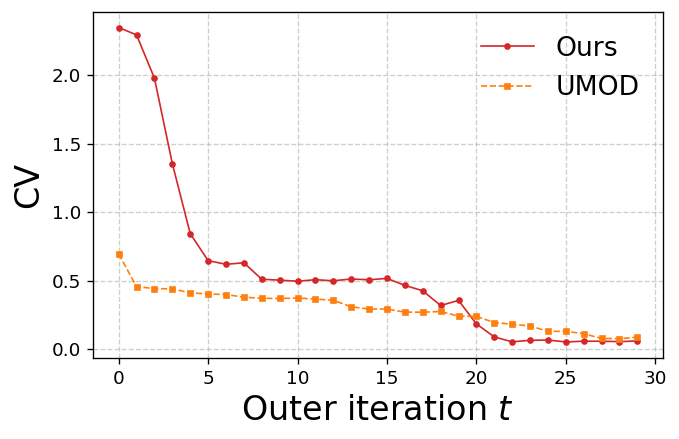

In [163]:
cdf_err, umod_err = plot_error_convergence_compare(
    out_cdf=out_cdf,
    out_umod=out_umod,
    umod_key="pf_reg_reward",
    if_ref=False,
    logy=False,
    x_axis="iteration",
    save_path=FIG_PATH + "Err_convergence_compare.pdf",
    title="Convergence of arc-length spacing error",
)

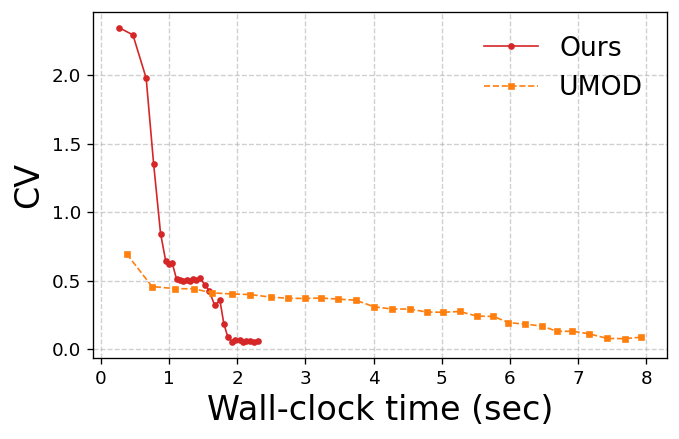

In [164]:
cdf_err, umod_err = plot_error_convergence_compare(
    out_cdf=out_cdf,
    out_umod=out_umod,
    umod_key="pf_reg_reward",
    if_ref=False,
    logy=False,
    x_axis="time",
    time_unit="sec",
    save_path=FIG_PATH + "Err_convergence_compare_time.pdf",
    title="Convergence of arc-length spacing error over time",
)

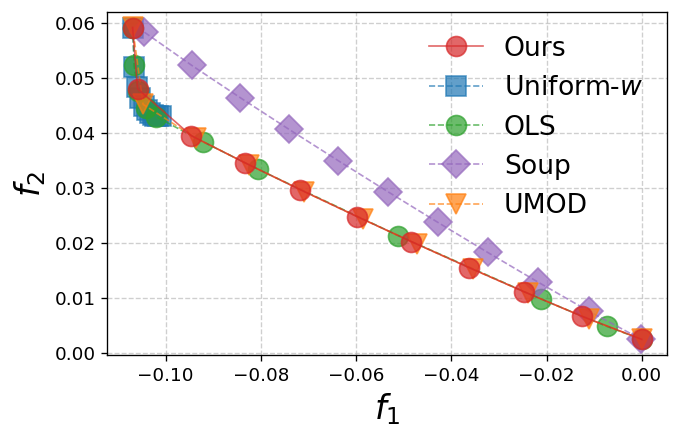

In [80]:
configs = [
    (out_uni,  "s", "--", r"Uniform-$w$"),
    (out_ols,  "o", "--", "OLS"),
    (out_soup, "D", "--", "Soup"),
    (out_umod, "v", "--", "UMOD"),
]
plot_converged_fronts_regularized(out_cdf, configs)

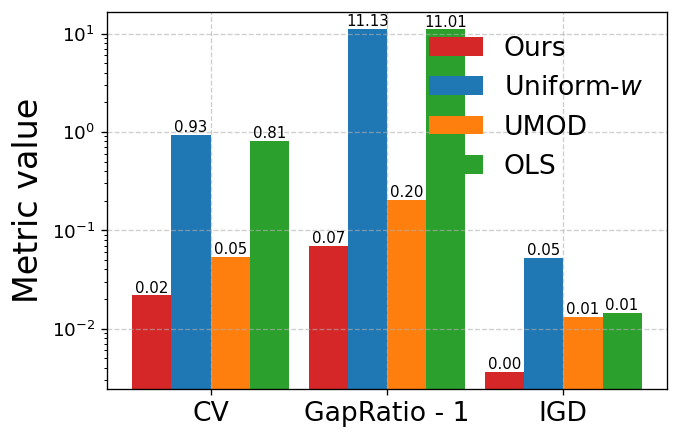

In [81]:
metrics = {
    "Ours": {
        "CV": arc_length_cv(pf_cdf),
        "GapRatio - 1": abs(max_min_gap_ratio(pf_cdf) - 1),
        "IGD": igd(pf_cdf),
    },
    r"Uniform-$w$": {
        "CV": arc_length_cv(pf_uni),
        "GapRatio - 1": abs(max_min_gap_ratio(pf_uni) - 1),
        "IGD": igd(pf_uni),
    },
    "UMOD": {
        "CV": arc_length_cv(pf_umod),
        "GapRatio - 1": abs(max_min_gap_ratio(pf_umod) - 1),
        "IGD": igd(pf_umod),
    },
    "OLS": {
        "CV": arc_length_cv(pf_ols),
        "GapRatio - 1": abs(max_min_gap_ratio(pf_ols) - 1),
        "IGD": igd(pf_ols),
    },
}


plot_metric_bars(metrics)

In [82]:
def rollout_trajectories(model, pi, num_steps=80, num_envs=4):
    """Generates stochastic rollouts for a single policy."""
    state_to_idx = model["state_to_idx"]
    idx_to_state = model["idx_to_state"]
    treasure_mask = model["treasure_mask"]
    P = model["P"] # (S, A, S) deterministic
    
    start_s_idx = np.argmax(model["rho0"])
    
    all_paths = []
    
    for _ in range(num_envs):
        curr_s_idx = start_s_idx
        path = [idx_to_state[curr_s_idx]]
        
        for _ in range(num_steps):
            if treasure_mask[curr_s_idx] or idx_to_state[curr_s_idx] == ("terminal",):
                break
                
            prob_dist = pi[curr_s_idx]
            # Probabilities must sum to 1.0
            s_val = np.sum(prob_dist)
            if s_val > 1e-9:
                prob_dist = prob_dist / s_val
                a = np.random.choice(model["A"], p=prob_dist)
            else:
                a = np.random.choice(model["A"]) # fallback
            
            # Deterministic next state
            curr_s_idx = np.argmax(P[curr_s_idx, a])
            curr_state = idx_to_state[curr_s_idx]
            if curr_state != ("terminal",):
                path.append(curr_state)
        
        all_paths.append(path)
    return all_paths

In [83]:
def plot_policy_trajectories_separately(
    model,
    policy_sol_list,
    tau,
    method_name="SURF Refinement (Our Method)",
    n_rollouts=30,
    max_steps=80,
    panel_width=3.6,
    panel_height=4.8,
    arrow_freq=4,
):
    """
    Always plot in a 1 x N layout, no matter how large N is.

    For each policy, show:
      - rollout trajectory distribution
      - average time cost over simulations
      - average obtained treasure reward over simulations

    Returns
    -------
    stats : list of dict
        One dict per policy with:
            policy_idx, w, avg_time_cost, avg_treasure_reward, success_rate
    """
    grid = model["grid"]
    N = len(policy_sol_list)

    fig, axs = plt.subplots(
        1,
        N,
        figsize=(panel_width * N, panel_height),
        constrained_layout=True,
        squeeze=False,
    )
    axs = axs[0]

    map_colors = {
        "wall": "#2B2B2B",
        "water": "#F4FBFD",
        "treasure": "#8C6A0A",
        "text": "#FFD700",
        "gridline": "#D6EAF0",
        "traj": "#1f77b4",
    }

    def draw_background(ax):
        ax.set_facecolor(map_colors["water"])

        # grid lines
        for x in np.arange(-0.5, grid.shape[1], 1):
            ax.axvline(x, color=map_colors["gridline"], lw=0.7, zorder=0)
        for y in np.arange(-0.5, grid.shape[0], 1):
            ax.axhline(y, color=map_colors["gridline"], lw=0.7, zorder=0)

        # draw cells
        for r in range(grid.shape[0]):
            for c in range(grid.shape[1]):
                val = grid[r, c]
                if val == -10:  # wall
                    ax.add_patch(
                        plt.Rectangle(
                            (c - 0.5, r - 0.5), 1, 1,
                            color=map_colors["wall"], zorder=1
                        )
                    )
                elif val > 0:  # treasure
                    ax.add_patch(
                        plt.Rectangle(
                            (c - 0.5, r - 0.5), 1, 1,
                            color=map_colors["treasure"], alpha=0.9, zorder=1
                        )
                    )
                    ax.text(
                        c, r, f"{int(val)}",
                        color=map_colors["text"],
                        ha="center", va="center",
                        fontweight="bold", 
                        fontsize=12, 
                        zorder=30
                    )

        ax.axis("image")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlim(-0.5, grid.shape[1] - 0.5)
        ax.set_ylim(grid.shape[0] - 0.5, -0.5)

    def path_stats(path):
        """
        Given one rollout path = [(r0,c0), (r1,c1), ...],
        compute:
          - time cost = number of actions = len(path)-1
          - obtained treasure reward = treasure value at final state if final state is treasure, else 0
        """
        if len(path) == 0:
            return {
                "time_cost": np.nan,
                "treasure_reward": np.nan,
                "success": False,
            }

        final_r, final_c = path[-1]
        final_val = grid[int(final_r), int(final_c)]
        treasure_reward = float(final_val) if final_val > 0 else 0.0
        time_cost = max(len(path) - 1, 0)
        success = final_val > 0

        return {
            "time_cost": float(time_cost),
            "treasure_reward": treasure_reward,
            "success": bool(success),
        }

    summary_stats = []

    for i, sol in enumerate(policy_sol_list):
        ax = axs[i]
        draw_background(ax)

        pi = sol["pi"]
        w = sol.get("w", None)

        # rollout_trajectories is assumed to return a list of paths,
        # each path being a list of (row, col) states
        paths = rollout_trajectories(
            model,
            pi,
            num_steps=max_steps,
            num_envs=n_rollouts
        )

        time_costs = []
        treasure_rewards = []
        successes = []

        for path in paths:
            path_coords = np.array(path)
            if len(path_coords) < 2:
                st = path_stats(path)
                if not np.isnan(st["time_cost"]):
                    time_costs.append(st["time_cost"])
                    treasure_rewards.append(st["treasure_reward"])
                    successes.append(float(st["success"]))
                continue

            X = path_coords[:, 1]
            Y = path_coords[:, 0]

            # faint overlap shows route distribution for this policy
            ax.plot(
                X, Y,
                color=map_colors["traj"],
                linewidth=1.2,
                alpha=0.10,
                zorder=3,
                solid_capstyle="round",
            )

            U = np.diff(X)
            V = np.diff(Y)
            idx = np.arange(0, len(U), arrow_freq)

            if len(idx) > 0:
                ax.quiver(
                    X[:-1][idx], Y[:-1][idx],
                    U[idx], V[idx],
                    angles="xy",
                    scale_units="xy",
                    scale=1,
                    color=map_colors["traj"],
                    alpha=0.12,
                    width=0.0035,
                    headwidth=4.0,
                    headlength=5.0,
                    headaxislength=4.5,
                    zorder=4,
                )

            ax.scatter(
                X[-1], Y[-1],
                s=10,
                color=map_colors["traj"],
                alpha=0.18,
                edgecolors="none",
                zorder=5,
            )

            st = path_stats(path)
            time_costs.append(st["time_cost"])
            treasure_rewards.append(st["treasure_reward"])
            successes.append(float(st["success"]))

        avg_time_cost = float(np.mean(time_costs)) if len(time_costs) > 0 else np.nan
        avg_treasure_reward = float(np.mean(treasure_rewards)) if len(treasure_rewards) > 0 else np.nan
        success_rate = float(np.mean(successes)) if len(successes) > 0 else np.nan

        summary_stats.append({
            "policy_idx": i + 1,
            "w": w,
            "avg_time_cost": avg_time_cost,
            "avg_treasure_reward": avg_treasure_reward,
            "success_rate": success_rate,
        })

        # subplot title
        if w is None:
            title_str = f"Policy {i+1}"
        else:
            title_str =  f"$w={w:.3f}$" # f"Policy {i+1}\n$w={w:.3f}$"

        ax.set_title(title_str, 
                     # fontsize=20, 
                     fontweight="bold")

        # show summary under each subplot
        stat_text = (
            f"Avg. time: {avg_time_cost:.1f}\n"
            f"Avg. treasure: {avg_treasure_reward:.1f}"
            # f"success: {100*success_rate:.1f}%"
        )
        ax.text(
            0.5, -0.03,
            stat_text,
            transform=ax.transAxes,
            ha="center", va="top",
            # fontsize=20
        )

    fig.suptitle(
        f"{method_name}: trajectory distribution ($\\tau$={tau})",
        fontsize=22,
        fontweight="bold"
    )
    plt.savefig(FIG_PATH+method_name+".pdf", bbox_inches="tight")
    
    plt.show()

    # Also print a clean summary table
    print(f"\n{method_name} summary over {n_rollouts} rollouts per policy")
    print("-" * 78)
    for row in summary_stats:
        w_str = "N/A" if row["w"] is None else f"{row['w']:.4f}"
        print(
            f"Policy {row['policy_idx']:>2} | "
            f"w = {w_str:>7} | "
            f"avg time cost = {row['avg_time_cost']:>6.2f} | "
            f"avg treasure = {row['avg_treasure_reward']:>6.2f} | "
            f"success = {100*row['success_rate']:>6.2f}%"
        )

    return summary_stats

In [84]:
N = 6

# Our method
out_cdf = solve_cdf_refinement_policy(
    N_points=N,
    P=P, R=R, rho0=rho0,
    gamma=gamma,
    tau=tau,
    pi_ref=pi_ref,
    max_outer_iters=30,
    alpha=0.3,
    inner_maxiter=100,
    inner_lr=0.02,
    logits0=sol0["logits"],
    logits1=sol1["logits"],
    init_from_prev=True,
    verbose=True,
)

pf_cdf = out_cdf["pf_history"][-1]

# Equi. Weights baseline
out_uni = run_equispace_weights_policy_baseline(
    N_points=N,
    P=P, R=R, rho0=rho0,
    gamma=gamma, tau=tau, pi_ref=pi_ref,
    inner_maxiter=30*100, inner_lr=0.02,
    logits0=sol0["logits"], logits1=sol1["logits"],
)
pf_uni = out_uni["pf"]


out_ols = run_ols_policy_baseline(
    N_points=N,
    P=P,
    R=R,
    rho0=rho0,
    gamma=gamma,
    tau=tau,
    pi_ref=pi_ref,
    inner_maxiter=30*100,
    inner_lr=0.02,
    inner_tol=1e-8,
    epsilon_ols=1e-6,
    logits0=sol0["logits"],
    logits1=sol1["logits"],
    init_mode="interp",
    device=DEVICE,
    verbose=True,
)

pf_ols = out_ols["pf"]

out_soup = run_soup_weights_measure_baseline(
    N_points=N,
    R=R,
    tau=tau,
    pi_ref=pi_ref,
    mu0=sol0["mu"],
    mu1=sol1["mu"],
    d_eps=1e-12,
)
pf_soup = out_soup["pf"]

out_umod = run_umod_policy_baseline_faithful(
    N_points=N,
    P=P,
    R=R,
    rho0=rho0,
    gamma=gamma,
    tau=tau,
    pi_ref=pi_ref,
    logits0=sol0["logits"],
    logits1=sol1["logits"],
    inner_maxiter=100,
    inner_lr=0.02,
    max_outer_iters=30,
    pf_model_epochs=100,
    Nopt=200,
    theta_step=1e-2,
    theta_eps=1e-3,   # try 5e-3 if endpoint duplicates remain
    device=DEVICE,
    verbose=True,
)

pf_umod = out_umod["pf"]

SURF CDF refinement started at 2026-05-03 22:24:17
N_points=6, max_outer_iters=30, inner_maxiter=100

--- Outer iteration 0 ---
start time: 2026-05-03 22:24:17
weights: [0.  0.2 0.4 0.6 0.8 1. ]
  [22:24:17] solving point 1/6, w=0.000000
  [22:24:17] finished point 1/6, elapsed=0.02s, R1=0.117914, R2=-0.047733
  [22:24:17] solving point 2/6, w=0.200000
  [22:24:17] finished point 2/6, elapsed=0.02s, R1=0.118912, R2=-0.034130
  [22:24:17] solving point 3/6, w=0.400000
  [22:24:17] finished point 3/6, elapsed=0.02s, R1=0.117612, R2=-0.028948
  [22:24:17] solving point 4/6, w=0.600000
  [22:24:17] finished point 4/6, elapsed=0.02s, R1=0.110669, R2=-0.024132
  [22:24:17] solving point 5/6, w=0.800000
  [22:24:17] finished point 5/6, elapsed=0.02s, R1=0.001039, R2=-0.001700
  [22:24:17] solving point 6/6, w=1.000000
  [22:24:17] finished point 6/6, elapsed=0.01s, R1=0.001022, R2=-0.001521
total PF length = 0.139512
outer elapsed = 0.12s
total elapsed = 0.12s
finished at: 2026-05-03 22:24:17

/Users/liuyuan/venvs/libmoon311/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain.py:336: FutureWarning: 
    Your problem is being solved with the ECOS solver by default. Starting in 
    CVXPY 1.5.0, Clarabel will be used as the default solver instead. To continue 
    using ECOS, specify the ECOS solver explicitly using the ``solver=cp.ECOS`` 
    argument to the ``problem.solve`` method.
    
  warnings.warn(ECOS_DEPRECATION_MSG, FutureWarning)


Adding value: [ 0.102 -0.043] to CCS.
[22:24:19] [OLS] query #03 finished  elapsed=0.17s  total_elapsed=0.25s  accepted=3/6  w=0.653423  value=[0.10202512, -0.04298539]  raw=[0.11974279, -0.02526773]  reg=0.01771767
W_corner: [array([1., 0.]), array([0.2842, 0.7158]), array([0.7678, 0.2322]), array([0., 1.])] W_corner size: 4
CCS: [array([ 0.1069, -0.0592]), array([ 1.3762e-05, -2.5300e-03]), array([ 0.102, -0.043])] CCS size: 3
Next weight: [0.2842 0.7158]

[2026-05-03 22:24:19] OLS query #04 started, w=0.715789
Adding value: [ 0.0511 -0.0214] to CCS.
[22:24:19] [OLS] query #04 finished  elapsed=0.11s  total_elapsed=0.35s  accepted=4/6  w=0.715789  value=[0.05111988, -0.02136846]  raw=[0.05944799, -0.01304035]  reg=0.00832811
W_corner: [array([1., 0.]), array([0.7678, 0.2322]), array([0.2979, 0.7021]), array([0.27, 0.73]), array([0., 1.])] W_corner size: 5
CCS: [array([ 0.1069, -0.0592]), array([ 1.3762e-05, -2.5300e-03]), array([ 0.102, -0.043]), array([ 0.0511, -0.0214])] CCS size: 

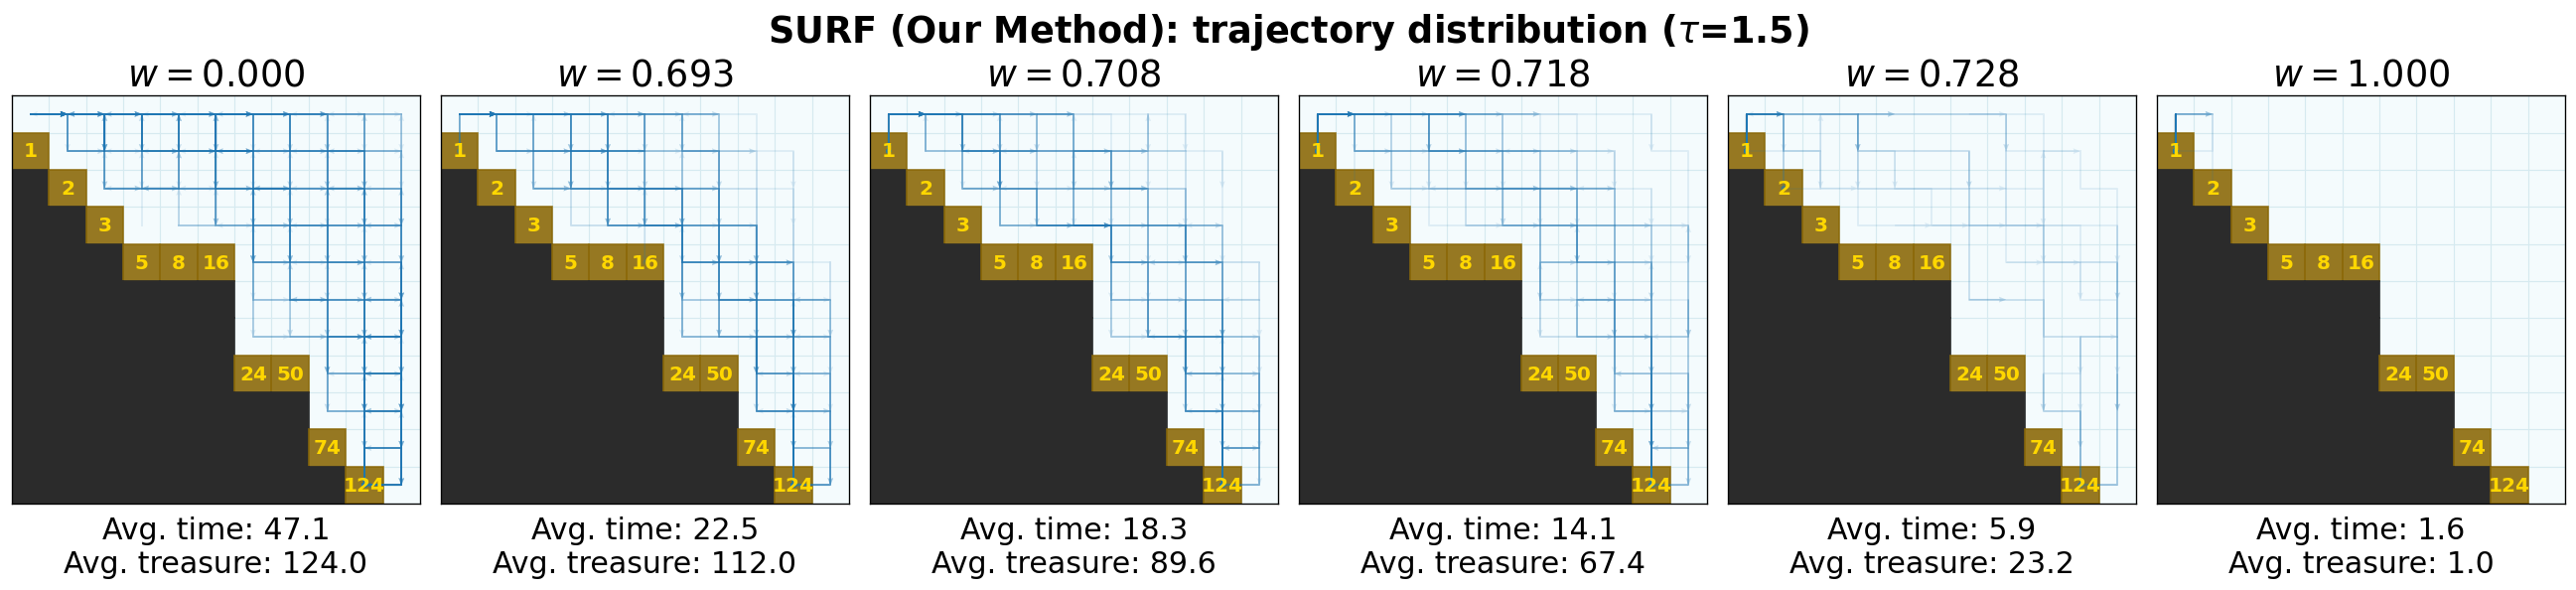


SURF (Our Method) summary over 50 rollouts per policy
------------------------------------------------------------------------------
Policy  1 | w =  0.0000 | avg time cost =  47.12 | avg treasure = 124.00 | success = 100.00%
Policy  2 | w =  0.6930 | avg time cost =  22.46 | avg treasure = 112.00 | success = 100.00%
Policy  3 | w =  0.7078 | avg time cost =  18.34 | avg treasure =  89.56 | success = 100.00%
Policy  4 | w =  0.7176 | avg time cost =  14.14 | avg treasure =  67.44 | success = 100.00%
Policy  5 | w =  0.7282 | avg time cost =   5.86 | avg treasure =  23.22 | success = 100.00%
Policy  6 | w =  1.0000 | avg time cost =   1.64 | avg treasure =   1.02 | success = 100.00%


In [85]:
results_cdf_last = out_cdf["policy_history"][-1]

stats_cdf = plot_policy_trajectories_separately(
    model,
    results_cdf_last,
    tau=tau,
    method_name="SURF (Our Method)",
    n_rollouts=50,
    max_steps=200,
)

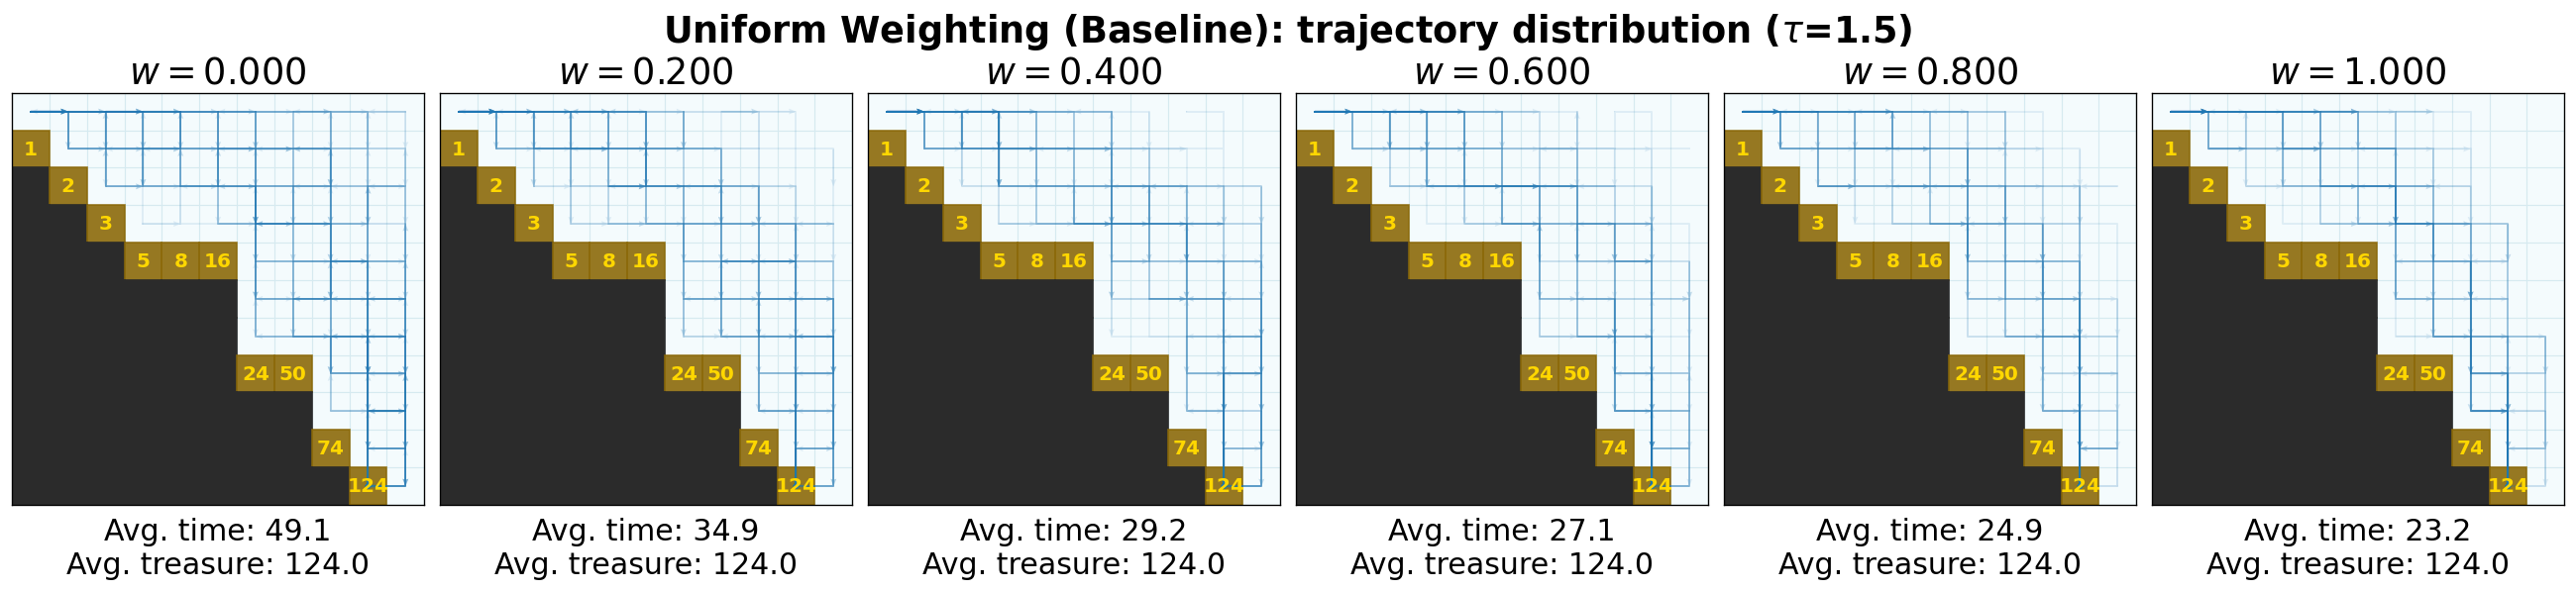


Uniform Weighting (Baseline) summary over 30 rollouts per policy
------------------------------------------------------------------------------
Policy  1 | w =  0.0000 | avg time cost =  49.13 | avg treasure = 124.00 | success = 100.00%
Policy  2 | w =  0.2000 | avg time cost =  34.93 | avg treasure = 124.00 | success = 100.00%
Policy  3 | w =  0.4000 | avg time cost =  29.20 | avg treasure = 124.00 | success = 100.00%
Policy  4 | w =  0.6000 | avg time cost =  27.10 | avg treasure = 124.00 | success = 100.00%
Policy  5 | w =  0.8000 | avg time cost =  24.90 | avg treasure = 124.00 | success = 100.00%
Policy  6 | w =  1.0000 | avg time cost =  23.20 | avg treasure = 124.00 | success = 100.00%


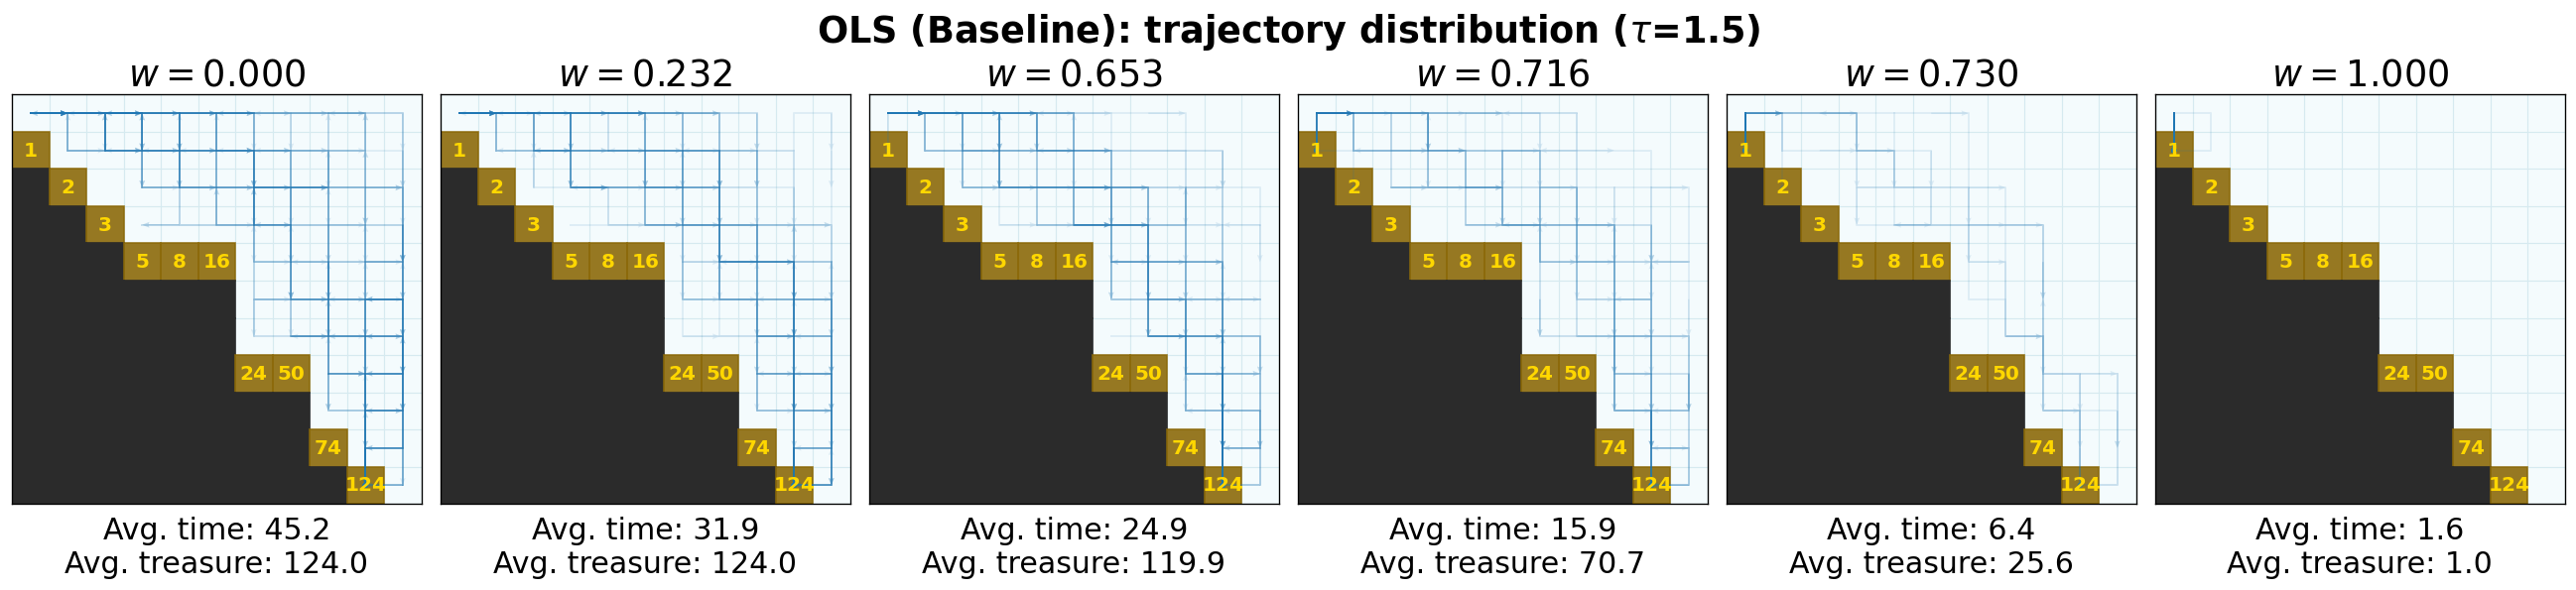


OLS (Baseline) summary over 30 rollouts per policy
------------------------------------------------------------------------------
Policy  1 | w =  0.0000 | avg time cost =  45.17 | avg treasure = 124.00 | success = 100.00%
Policy  2 | w =  0.2322 | avg time cost =  31.90 | avg treasure = 124.00 | success = 100.00%
Policy  3 | w =  0.6534 | avg time cost =  24.87 | avg treasure = 119.90 | success = 100.00%
Policy  4 | w =  0.7158 | avg time cost =  15.93 | avg treasure =  70.73 | success = 100.00%
Policy  5 | w =  0.7300 | avg time cost =   6.40 | avg treasure =  25.63 | success = 100.00%
Policy  6 | w =  1.0000 | avg time cost =   1.63 | avg treasure =   1.00 | success = 100.00%


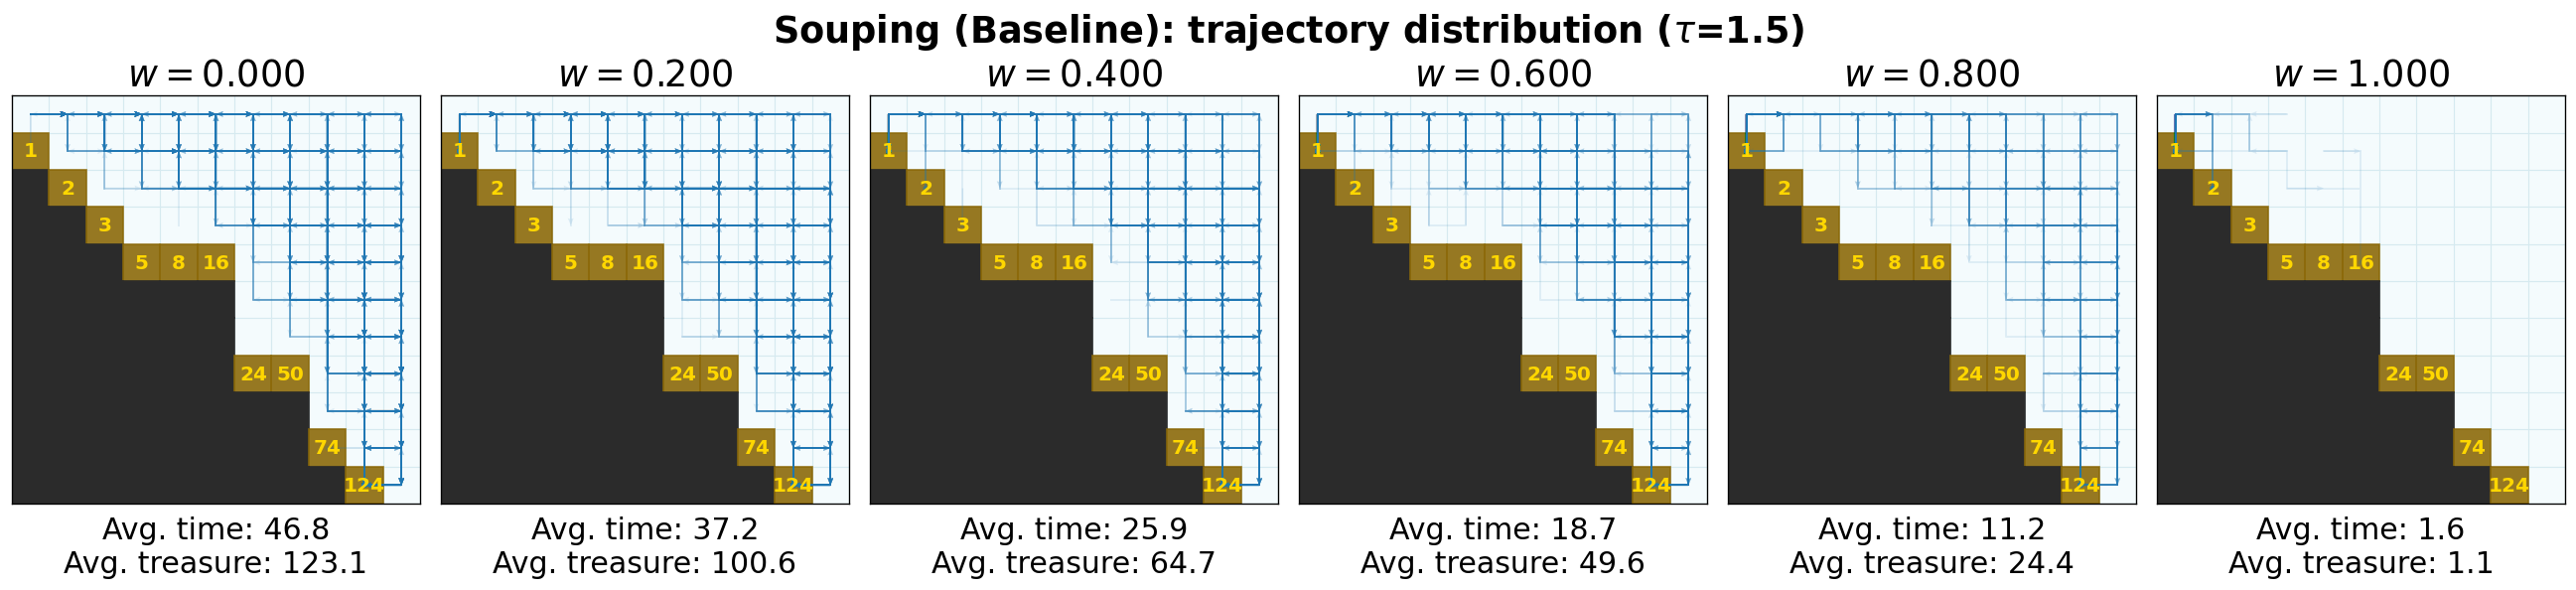


Souping (Baseline) summary over 200 rollouts per policy
------------------------------------------------------------------------------
Policy  1 | w =  0.0000 | avg time cost =  46.76 | avg treasure = 123.14 | success = 100.00%
Policy  2 | w =  0.2000 | avg time cost =  37.22 | avg treasure = 100.63 | success = 100.00%
Policy  3 | w =  0.4000 | avg time cost =  25.95 | avg treasure =  64.74 | success = 100.00%
Policy  4 | w =  0.6000 | avg time cost =  18.66 | avg treasure =  49.60 | success = 100.00%
Policy  5 | w =  0.8000 | avg time cost =  11.23 | avg treasure =  24.37 | success = 100.00%
Policy  6 | w =  1.0000 | avg time cost =   1.64 | avg treasure =   1.11 | success = 100.00%


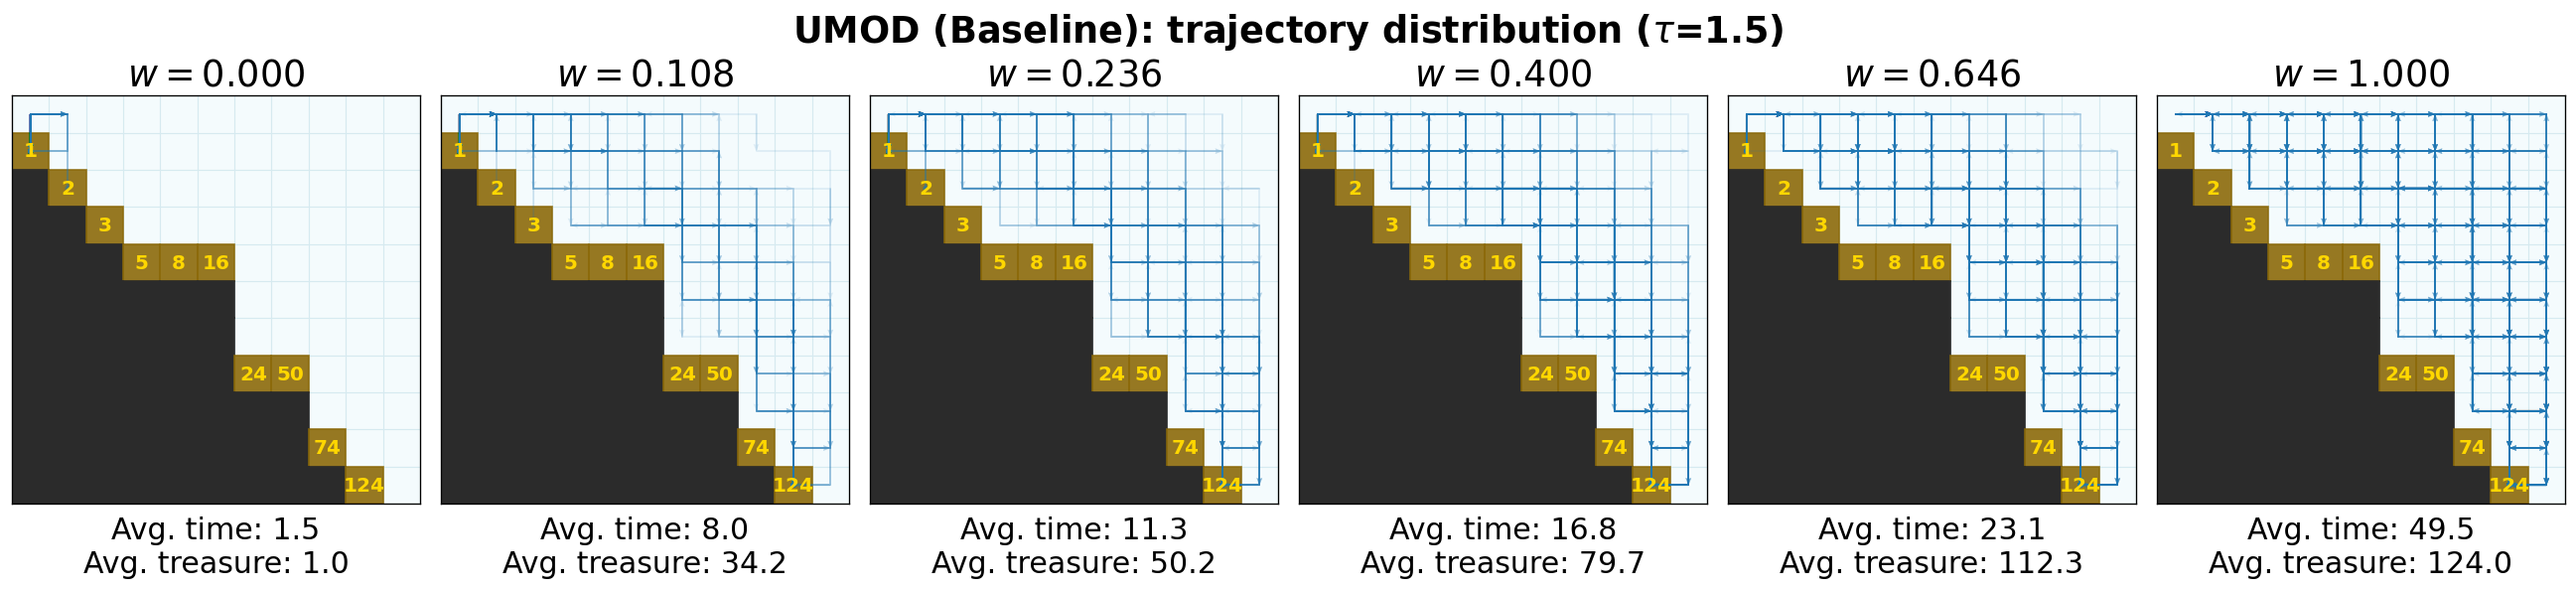


UMOD (Baseline) summary over 200 rollouts per policy
------------------------------------------------------------------------------
Policy  1 | w =  0.0000 | avg time cost =   1.50 | avg treasure =   1.01 | success = 100.00%
Policy  2 | w =  0.1084 | avg time cost =   8.02 | avg treasure =  34.23 | success = 100.00%
Policy  3 | w =  0.2356 | avg time cost =  11.33 | avg treasure =  50.23 | success = 100.00%
Policy  4 | w =  0.3996 | avg time cost =  16.80 | avg treasure =  79.73 | success = 100.00%
Policy  5 | w =  0.6457 | avg time cost =  23.06 | avg treasure = 112.31 | success = 100.00%
Policy  6 | w =  1.0000 | avg time cost =  49.48 | avg treasure = 124.00 | success = 100.00%


In [86]:
def get_results_list(obj):
    if isinstance(obj, dict) and "results" in obj:
        return obj["results"]
    return obj

stats_uni = plot_policy_trajectories_separately(
    model,
    get_results_list(out_uni),
    tau=tau,
    method_name="Uniform Weighting (Baseline)",
    n_rollouts=30,
    max_steps=200,
)


stats_ols = plot_policy_trajectories_separately(
    model,
    get_results_list(out_ols),
    tau=tau,
    method_name="OLS (Baseline)",
    n_rollouts=30,
    max_steps=200,
)

stats_soup = plot_policy_trajectories_separately(
    model,
    get_results_list(out_soup),
    tau=tau,
    method_name="Souping (Baseline)",
    n_rollouts=200,
    max_steps=200,
)

stats_umod = plot_policy_trajectories_separately(
    model,
    get_results_list(out_umod),
    tau=tau,
    method_name="UMOD (Baseline)",
    n_rollouts=200,
    max_steps=200,
)

In [87]:
def maybe_reverse_pf(pf, ref_pf = out_cdf_dense["pf_history"][-1]):
    pf = np.asarray(pf, dtype=float)
    ref_pf = np.asarray(ref_pf, dtype=float)

    d_same = np.linalg.norm(pf[0] - ref_pf[0]) + np.linalg.norm(pf[-1] - ref_pf[-1])
    d_flip = np.linalg.norm(pf[0] - ref_pf[-1]) + np.linalg.norm(pf[-1] - ref_pf[0])
    return pf if d_same <= d_flip else pf[:-1]


def reference_arc_cdf_from_dense_pf(ref_pf = out_cdf_dense["pf_history"][-1]):
    """
    Build arc-length parameterization on a dense reference PF.
    Returns normalized cumulative arc positions at each reference node.
    """
    ref_pf = np.asarray(ref_pf, dtype=float)
    seg = np.linalg.norm(np.diff(ref_pf, axis=0), axis=1)
    s = np.concatenate([[0.0], np.cumsum(seg)])
    if s[-1] <= 1e-14:
        raise RuntimeError("Reference PF has near-zero arc length.")
    return s / s[-1]


def project_pf_to_ref_arc(pf, ref_pf, ref_cdf):
    """
    Project each point of pf onto the polyline ref_pf and return its normalized
    arc-length coordinate on the reference PF.
    """
    pf = np.asarray(pf, dtype=float)
    ref_pf = np.asarray(ref_pf, dtype=float)
    ref_cdf = np.asarray(ref_cdf, dtype=float)

    pf = maybe_reverse_pf(pf, ref_pf)

    seg_vecs = ref_pf[1:] - ref_pf[:-1]
    seg_lens = np.linalg.norm(seg_vecs, axis=1)
    total_len = np.sum(seg_lens)

    vals = []
    for y in pf:
        best_dist2 = np.inf
        best_arc = 0.0

        for j in range(len(seg_vecs)):
            a = ref_pf[j]
            v = seg_vecs[j]
            L2 = np.dot(v, v)

            if L2 <= 1e-20:
                t = 0.0
                proj = a
            else:
                t = np.dot(y - a, v) / L2
                t = np.clip(t, 0.0, 1.0)
                proj = a + t * v

            dist2 = np.sum((y - proj) ** 2)
            if dist2 < best_dist2:
                best_dist2 = dist2
                # ref_cdf[j] corresponds to the node at a
                best_arc = ref_cdf[j] + (seg_lens[j] / total_len) * t

        vals.append(best_arc)

    vals = np.asarray(vals, dtype=float)

    # enforce monotonicity lightly
    vals = np.maximum.accumulate(vals)
    vals[0] = 0.0
    vals[-1] = 1.0
    return vals


def build_Farc_proxy_on_wfine(out_cdf, ref_pf, w_fine=None):
    """
    For each outer iteration t:
      - take current sampled PF and sampled weights,
      - compute reference-arc positions of those PF points,
      - interpolate those arc positions as a function of weight onto w_fine.

    Returns:
      Farc_proxy_history: list of arrays on w_fine
      err_inf_history: sup norm ||\Phi_t - Farc_proxy_t||_inf
      w_fine
    """
    ref_pf = np.asarray(ref_pf, dtype=float)
    ref_cdf = reference_arc_cdf_from_dense_pf(ref_pf)

    if w_fine is None:
        w_fine = np.asarray(out_cdf["F_history"][0], dtype=float)
        w_fine = np.linspace(0.0, 1.0, len(w_fine))
    else:
        w_fine = np.asarray(w_fine, dtype=float)

    Farc_proxy_history = []
    err_inf_history = []

    for Phi_t, w_t, pf_t in zip(out_cdf["F_history"], out_cdf["weight_history"], out_cdf["pf_history"]):
        w_t = np.asarray(w_t, dtype=float)
        pf_t = np.asarray(pf_t, dtype=float)
        Phi_t = np.asarray(Phi_t, dtype=float)

        # make sure weight ordering is increasing
        order = np.argsort(w_t)
        w_t = w_t[order]
        pf_t = pf_t[order]

        # reference arc values of current PF points
        arc_vals = project_pf_to_ref_arc(pf_t, ref_pf, ref_cdf)

        # interpolate to the same fine grid as Phi_t
        interp = PchipInterpolator(w_t, arc_vals, extrapolate=False)
        Farc_t = interp(w_fine)

        # fill boundaries if needed
        Farc_t = np.asarray(Farc_t, dtype=float)
        Farc_t[w_fine < w_t[0]] = arc_vals[0]
        Farc_t[w_fine > w_t[-1]] = arc_vals[-1]

        Farc_proxy_history.append(Farc_t)
        err_inf_history.append(np.max(np.abs(Phi_t - Farc_t)))

    return {
        "w_fine": w_fine,
        "Farc_proxy_history": Farc_proxy_history,
        "err_inf_history": np.asarray(err_inf_history, dtype=float),
    }

def plot_F_minus_Farc_proxy_convergence_clean(
    out_cdf,
    alpha=0.3,
    ref_pf=None,
    ref_w=None,
    floor_mode="theory",
    log_y=False,
):
    """
    Plot ||\Phi_t - \hat F_arc||_inf together with an upper guide of the form

        C0 * (1 - alpha/4)^t + tail

    where by default
        tail = kappa^2 / N^2,
        kappa = max F'_arc / min F'_arc,

    approximated from a dense reference PF.

    Args:
        out_cdf: output dict from solve_cdf_refinement_policy
        alpha: outer update parameter
        ref_pf: dense reference PF, default out_cdf_dense["pf_history"][-1]
        ref_w:  weights corresponding to ref_pf, default out_cdf_dense["weight_history"][-1]
        floor_mode: "theory" or "empirical"
        log_y: whether to use semilogy
    """
    if ref_pf is None:
        ref_pf = out_cdf_dense["pf_history"][-1]
    if ref_w is None:
        ref_w = out_cdf_dense["weight_history"][-1]

    ref_pf = np.asarray(ref_pf, dtype=float)
    ref_w = np.asarray(ref_w, dtype=float)

    # sort by weight just in case
    order = np.argsort(ref_w)
    ref_w = ref_w[order]
    ref_pf = ref_pf[order]

    # build dense reference F_arc(w)
    diffs = np.diff(ref_pf, axis=0)
    seg_lens = np.sqrt(np.sum(diffs ** 2, axis=1))
    s_vals = np.concatenate([[0.0], np.cumsum(seg_lens)])
    total_len = s_vals[-1]
    if total_len <= 1e-14:
        raise RuntimeError("Reference PF has near-zero arc length.")

    Farc_vals = s_vals / total_len

    # interpolate F_arc onto a fine w-grid
    w_fine = np.linspace(ref_w[0], ref_w[-1], 2001)
    interp_Farc = PchipInterpolator(ref_w, Farc_vals)
    Farc_fine = interp_Farc(w_fine)

    # derivative F'_arc(w)
    Farc_prime = np.gradient(Farc_fine, w_fine)
    eps = 1e-12
    Farc_prime = np.clip(Farc_prime, eps, None)

    kappa = 2 #np.max(Farc_prime) / np.min(Farc_prime)
    N = len(out_cdf["weight_history"][0]) - 1
    theory_tail = (kappa ** 2) / (N ** 2)

    # compute proxy errors
    diag = build_Farc_proxy_on_wfine(out_cdf, ref_pf, w_fine=w_fine)
    errs = diag["err_inf_history"]
    t_axis = np.arange(len(errs))

    if floor_mode == "theory":
        tail = theory_tail
    elif floor_mode == "empirical":
        tail = float(np.median(errs[-6:])) if len(errs) >= 6 else float(errs[-1])
    else:
        raise ValueError("floor_mode must be 'theory' or 'empirical'.")

    rate = 1.0 - alpha / 4.0

    # choose C0 so the guide upper-bounds all observed errors
    shifted = np.maximum(errs - tail, 0.0)
    C0 = 0.5 # np.max(shifted / np.maximum(rate ** t_axis, 1e-16))
    # C0 *= 1.02  # small padding so guide is visibly above the curve

    guide = tail + C0 * (rate ** t_axis)

    plt.figure(figsize=(7, 5))
    if log_y:
        plt.semilogy(
            t_axis, errs, marker="o", linewidth=2,
            label=r"$\|\Phi_t-\hat F_{\mathrm{arc}}\|_\infty$"
        )
        plt.semilogy(
            t_axis, guide, "--", linewidth=2,
            label=rf"guide: $C_0(1-\alpha/4)^t + \kappa^2/N^2$"
        )
        plt.axhline(
            tail, color="k", linestyle=":", linewidth=1.5,
            label=rf"$\kappa^2/N^2 \approx {tail:.3e}$"
        )
    else:
        plt.plot(
            t_axis, errs, marker="o", linewidth=2,
            label=r"$\|\Phi_t-\hat F_{\mathrm{arc}}\|_\infty$"
        )
        plt.plot(
            t_axis, guide, "--", linewidth=2,
            label=rf"guide: $C_0(1-\alpha/4)^t + \kappa^2/N^2$"
        )
        plt.axhline(
            tail, color="k", linestyle=":", linewidth=1.5,
            label=rf"$\kappa^2/N^2 \approx {tail:.3e}$"
        )

    plt.xlabel(r"Outer iteration $t$")
    plt.ylabel("Sup-norm error")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"kappa           = {kappa:.6e}")
    print(f"N               = {N}")
    print(f"kappa^2 / N^2   = {theory_tail:.6e}")
    print(f"rate            = 1 - alpha/4 = {rate:.6f}")
    print(f"chosen C0       = {C0:.6e}")

    return {
        "errs": errs,
        "guide": guide,
        "tail": tail,
        "kappa": kappa,
        "N": N,
        "C0": C0,
        "rate": rate,
        "w_fine": w_fine,
        "Farc_fine": Farc_fine,
        "Farc_prime": Farc_prime,
        **diag,
    }

### Ablation

In [112]:
alphas = [0.1, 0.2, 0.3, 0.5, 0.8]
inner_maxiters = [1, 2, 5, 10, 20, 30, 100]
ref_pf = out_cdf_dense["pf_history"][-1]
ref_w  = out_cdf_dense["weight_history"][-1]
init_from_prev=True

In [113]:
# ------------------------------------------------------------
# Basic PF spacing metrics
# ------------------------------------------------------------

def pf_segment_lengths(pf):
    pf = np.asarray(pf, dtype=float)
    if len(pf) < 2:
        return np.array([])
    return np.linalg.norm(np.diff(pf, axis=0), axis=1)

def pf_spacing_cv(pf):
    seg = pf_segment_lengths(pf)
    if len(seg) == 0:
        return np.nan
    m = np.mean(seg)
    if m <= 1e-15:
        return np.nan
    return np.std(seg) / m

def pf_gap_ratio(pf):
    seg = pf_segment_lengths(pf)
    if len(seg) == 0:
        return np.nan
    mn = np.min(seg)
    mx = np.max(seg)
    if mn <= 1e-15:
        return np.inf
    return mx / mn

def compute_igd_to_ref(pf, ref_pf):
    pf = np.asarray(pf, dtype=float)
    ref_pf = np.asarray(ref_pf, dtype=float)
    dists = []
    for y in ref_pf:
        d = np.min(np.linalg.norm(pf - y, axis=1))
        dists.append(d)
    return float(np.mean(dists))

In [114]:
def compute_Farc_proxy_error_history(out_cdf, ref_pf, ref_w, w_fine=None):
    ref_pf = np.asarray(ref_pf, dtype=float)
    ref_w = np.asarray(ref_w, dtype=float)

    order = np.argsort(ref_w)
    ref_w = ref_w[order]
    ref_pf = ref_pf[order]

    if w_fine is None:
        w_fine = np.linspace(ref_w[0], ref_w[-1], 2001)

    diag = build_Farc_proxy_on_wfine(out_cdf, ref_pf, w_fine=w_fine)
    return {
        "w_fine": diag["w_fine"],
        "err_inf_history": np.asarray(diag["err_inf_history"], dtype=float),
        "Farc_proxy_history": diag["Farc_proxy_history"],
    }

def evaluate_cdf_run(out_cdf, ref_pf, ref_w):
    diag = compute_Farc_proxy_error_history(out_cdf, ref_pf, ref_w)
    err_hist = diag["err_inf_history"]

    pf_final = np.asarray(out_cdf["pf_history"][-1], dtype=float)

    metrics = {
        "err_inf_history": err_hist,
        "err_inf_final": float(err_hist[-1]),
        "cv_final": float(pf_spacing_cv(pf_final)),
        "gap_ratio_final": float(pf_gap_ratio(pf_final)),
        "igd_final": float(compute_igd_to_ref(pf_final, np.asarray(ref_pf))),
    }
    return metrics

def run_cdf_tryout_grid_with_N(
    Ns,
    alphas,
    inner_maxiters,
    P, R, rho0,
    gamma, tau, pi_ref,
    logits0, logits1,
    max_outer_iters=30,
    inner_lr=0.02,
    init_from_prev=True,
    verbose=False,
    ref_pf=None,
    ref_w=None,
):
    results = []

    for N_points, alpha, inner_maxiter in product(Ns, alphas, inner_maxiters):
        print(f"Running N={N_points}, alpha={alpha}, inner_maxiter={inner_maxiter}")

        out = solve_cdf_refinement_policy(
            N_points=N_points,
            P=P, R=R, rho0=rho0,
            gamma=gamma,
            tau=tau,
            pi_ref=pi_ref,
            max_outer_iters=max_outer_iters,
            alpha=alpha,
            inner_maxiter=inner_maxiter,
            inner_lr=inner_lr,
            logits0=logits0,
            logits1=logits1,
            init_from_prev=init_from_prev,
            verbose=verbose,
        )

        evals = evaluate_cdf_run(out, ref_pf=ref_pf, ref_w=ref_w)

        results.append({
            "N": N_points,
            "alpha": alpha,
            "inner_maxiter": inner_maxiter,
            "out": out,
            **evals,
        })

    return results

In [115]:
def _plot_curve(x, y, log_y, **kwargs):
    if log_y:
        plt.semilogy(x, y, **kwargs)
    else:
        plt.plot(x, y, **kwargs)

def plot_err_histories_by_alpha(results, fixed_inner_maxiter, log_y=False):
    # plt.figure(figsize=(7,5))

    subset = [r for r in results if r["inner_maxiter"] == fixed_inner_maxiter]
    subset = sorted(subset, key=lambda r: r["alpha"])

    for r in subset:
        t = np.arange(len(r["err_inf_history"]))
        label = rf"$\alpha={r['alpha']}$"

        _plot_curve(
            t,
            r["err_inf_history"],
            log_y,
            # marker="o",
            # linewidth=2,
            label=label,
            alpha = 0.9,
        )

    plt.xlabel(r"Outer iteration $t$")
    plt.ylabel(r"$\|\Phi_t-\Phi\|_\infty$")
    plt.title(rf"Varying $\alpha$ (K={fixed_inner_maxiter})")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_PATH+f"Varying alpha (K={fixed_inner_maxiter}).pdf", bbox_inches="tight")
    plt.show()

def plot_err_histories_by_innerK(results, fixed_alpha, log_y=False):
    # plt.figure(figsize=(7,5))

    subset = [r for r in results if np.isclose(r["alpha"], fixed_alpha)]
    subset = sorted(subset, key=lambda r: r["inner_maxiter"])

    for r in subset:
        t = np.arange(len(r["err_inf_history"]))
        label = rf"$K={r['inner_maxiter']}$"

        _plot_curve(
            t,
            r["err_inf_history"],
            log_y,
            # marker="o",
            # linewidth=2,
            label=label,
            alpha = 0.9,
        )

    plt.xlabel(r"Outer iteration $t$")
    plt.ylabel(r"$\|\Phi_t-\Phi\|_\infty$")
    plt.title(rf"Varying $K$ ($\alpha$={fixed_alpha})")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_PATH+f"Varying inner steps (alpha={fixed_alpha}).pdf", bbox_inches="tight")
    plt.show()

def plot_err_histories_by_N(results, fixed_alpha, fixed_inner_maxiter, log_y=False):
    # plt.figure(figsize=(7,5))

    subset = [
        r for r in results
        if np.isclose(r["alpha"], fixed_alpha) and r["inner_maxiter"] == fixed_inner_maxiter
    ]
    subset = sorted(subset, key=lambda r: r["N"])

    for r in subset:
        t = np.arange(len(r["err_inf_history"]))
        label = rf"$N={r['N']}$"

        _plot_curve(
            t,
            r["err_inf_history"],
            log_y,
            # marker="o",
            # linewidth=2,
            label=label,
            alpha = 0.9,
        )

    plt.xlabel(r"Outer iteration $t$")
    plt.ylabel(r"$\|\Phi_t-\Phi\|_\infty$")
    plt.title(rf"Varying $N$ ($\alpha$={fixed_alpha}, K={fixed_inner_maxiter})")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_PATH+f"Varying N (alpha={fixed_alpha}, K={fixed_inner_maxiter}).pdf", bbox_inches="tight")
    plt.show()

In [119]:
# alphas = [0.1, 0.2, 0.3, 0.5, 0.8]
Ns = [11]
alphas = [0.2, 0.3, 0.5, 0.6,0.7,0.9]
inner_maxiters = [10, 20, 30, 100]

results = run_cdf_tryout_grid_with_N(
    Ns=Ns,
    alphas=alphas,
    inner_maxiters=inner_maxiters,
    P=P, R=R, rho0=rho0,
    gamma=gamma, tau=tau, pi_ref=pi_ref,
    logits0=sol0["logits"],
    logits1=sol1["logits"],
    max_outer_iters=60,
    inner_lr=0.02,
    init_from_prev=True,
    verbose=False,
    ref_pf=out_cdf_dense["pf_history"][-1],
    ref_w=out_cdf_dense["weight_history"][-1],
)

Running N=11, alpha=0.2, inner_maxiter=10
Running N=11, alpha=0.2, inner_maxiter=20
Running N=11, alpha=0.2, inner_maxiter=30
Running N=11, alpha=0.2, inner_maxiter=100
Running N=11, alpha=0.3, inner_maxiter=10
Running N=11, alpha=0.3, inner_maxiter=20
Running N=11, alpha=0.3, inner_maxiter=30
Running N=11, alpha=0.3, inner_maxiter=100
Running N=11, alpha=0.5, inner_maxiter=10
Running N=11, alpha=0.5, inner_maxiter=20
Running N=11, alpha=0.5, inner_maxiter=30
Running N=11, alpha=0.5, inner_maxiter=100
Running N=11, alpha=0.6, inner_maxiter=10
Running N=11, alpha=0.6, inner_maxiter=20
Running N=11, alpha=0.6, inner_maxiter=30
Running N=11, alpha=0.6, inner_maxiter=100
Running N=11, alpha=0.7, inner_maxiter=10
Running N=11, alpha=0.7, inner_maxiter=20
Running N=11, alpha=0.7, inner_maxiter=30
Running N=11, alpha=0.7, inner_maxiter=100
Running N=11, alpha=0.9, inner_maxiter=10
Running N=11, alpha=0.9, inner_maxiter=20
Running N=11, alpha=0.9, inner_maxiter=30
Running N=11, alpha=0.9, inne

In [120]:
Ns = [6, 11, 16, 26,51]
alphas = [0.3]
inner_maxiters = [100]

results_N = run_cdf_tryout_grid_with_N(
    Ns=Ns,
    alphas=alphas,
    inner_maxiters=inner_maxiters,
    P=P, R=R, rho0=rho0,
    gamma=gamma, tau=tau, pi_ref=pi_ref,
    logits0=sol0["logits"],
    logits1=sol1["logits"],
    max_outer_iters=60,
    inner_lr=0.02,
    init_from_prev=True,
    verbose=False,
    ref_pf=out_cdf_dense["pf_history"][-1],
    ref_w=out_cdf_dense["weight_history"][-1],
)

Running N=6, alpha=0.3, inner_maxiter=100
Running N=11, alpha=0.3, inner_maxiter=100
Running N=16, alpha=0.3, inner_maxiter=100
Running N=26, alpha=0.3, inner_maxiter=100
Running N=51, alpha=0.3, inner_maxiter=100


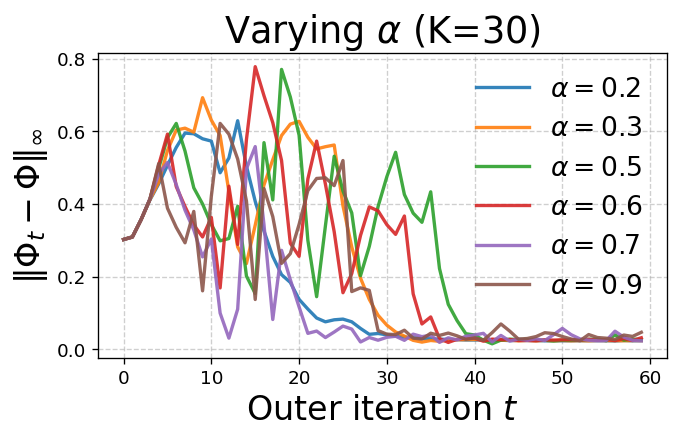

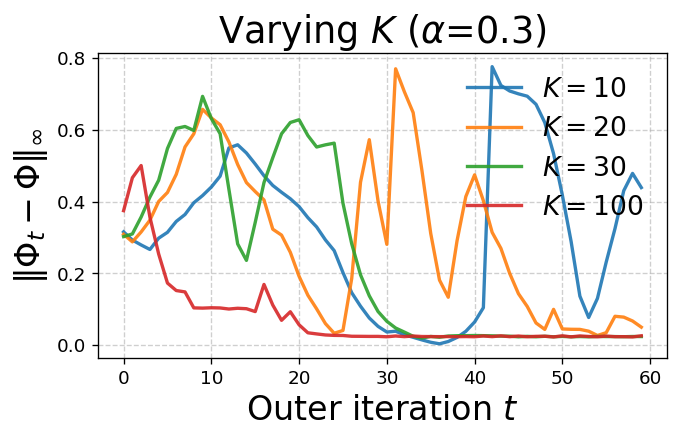

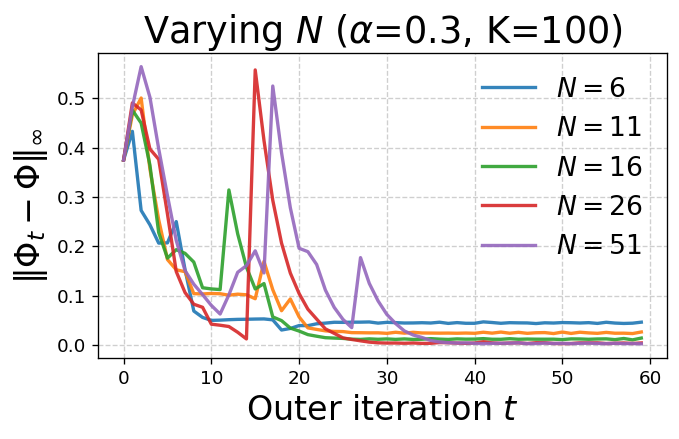

In [121]:
plot_err_histories_by_alpha(results, fixed_inner_maxiter=30)
plot_err_histories_by_innerK(results, fixed_alpha=0.3)
plot_err_histories_by_N(results_N, fixed_alpha=0.3, fixed_inner_maxiter=100)

In [125]:
def plot_final_err_vs_N_with_ref(results_N, fixed_alpha, fixed_inner_maxiter, save_path=None):
    subset = [
        r for r in results_N
        if np.isclose(r["alpha"], fixed_alpha)
        and r["inner_maxiter"] == fixed_inner_maxiter
    ]
    subset = sorted(subset, key=lambda r: r["N"])

    if len(subset) == 0:
        raise ValueError("No matching runs found for the given alpha and inner_maxiter.")

    Ns = np.array([r["N"] for r in subset], dtype=float)
    errs = np.array([r["err_inf_history"][-1] for r in subset], dtype=float)

    plt.figure(figsize=(7, 5))
    plt.plot(Ns, errs, marker="o", label="final error", alpha=0.9)

    mask = (Ns > 0) & (errs > 0)

    # Reference slope: Error proportional to N^{-2}, anchored at the first valid point
    if np.sum(mask) >= 1:
        ref_idx = 0
        ref_c = errs[mask][ref_idx] * Ns[mask][ref_idx]**2
        ref_curve = ref_c * Ns**(-2)

        plt.plot(
            Ns,
            ref_curve,
            linestyle=":",
            linewidth=2,
            label=r"reference: $N^{-2}$",
        )

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(r"$N$")
    plt.ylabel(r"$\|\Phi_t-\Phi\|_\infty$")
    plt.title(rf"Final error vs. $N$ ($\alpha$={fixed_alpha}, K={fixed_inner_maxiter})")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()

In [143]:
Ns = [5,7,9,11,13,15,17,19,21]
alphas = [0.1]
inner_maxiters = [200]

results_N_more = run_cdf_tryout_grid_with_N(
    Ns=Ns,
    alphas=alphas,
    inner_maxiters=inner_maxiters,
    P=P, R=R, rho0=rho0,
    gamma=gamma, tau=tau, pi_ref=pi_ref,
    logits0=sol0["logits"],
    logits1=sol1["logits"],
    max_outer_iters=100,
    inner_lr=0.02,
    init_from_prev=True,
    verbose=False,
    ref_pf=out_cdf_dense["pf_history"][-1],
    ref_w=out_cdf_dense["weight_history"][-1],
)

Running N=5, alpha=0.1, inner_maxiter=200
Running N=7, alpha=0.1, inner_maxiter=200
Running N=9, alpha=0.1, inner_maxiter=200
Running N=11, alpha=0.1, inner_maxiter=200
Running N=13, alpha=0.1, inner_maxiter=200
Running N=15, alpha=0.1, inner_maxiter=200
Running N=17, alpha=0.1, inner_maxiter=200
Running N=19, alpha=0.1, inner_maxiter=200
Running N=21, alpha=0.1, inner_maxiter=200


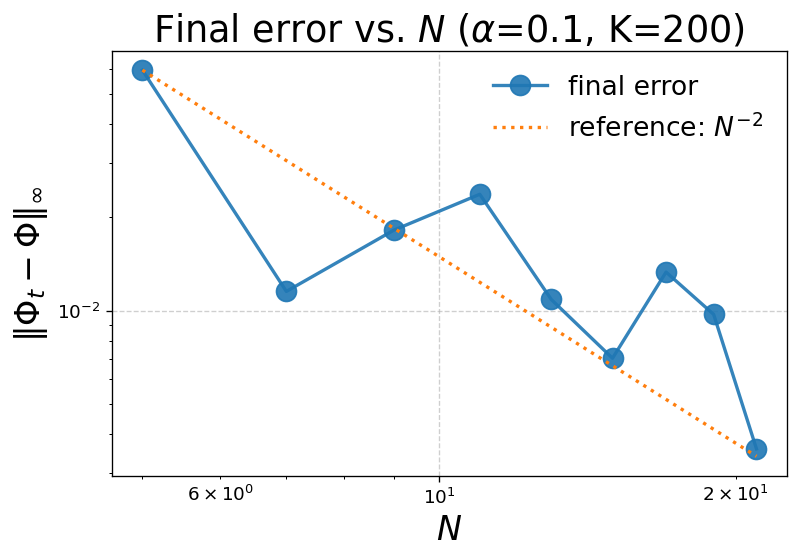

In [145]:
plot_final_err_vs_N_with_ref(
    results_N_more,
    fixed_alpha=0.1,
    fixed_inner_maxiter=200,
    save_path=FIG_PATH + "final_err_vs_N_with_Nminus2_ref.pdf",
)

### Verify the conditions that enables hidden convexity in occupancy measure space

In [39]:
# Active-state trimming: remove absorbing terminal state
def get_active_model_arrays(model):
    terminal_idx = model["terminal_idx"]
    keep = [i for i in range(model["S"]) if i != terminal_idx]

    P_active = model["P"][np.ix_(keep, range(model["A"]), keep)]
    R_active = model["R"][np.ix_(keep, range(model["A"]), range(model["R"].shape[2]))]
    rho0_active = model["rho0"][keep]

    return P_active, R_active, rho0_active, keep



# Policy -> discounted occupancy on active states x actions
def policy_to_discounted_occupancy_active(pi, P_sa_s, rho0, gamma):
    S, A = pi.shape

    P_pi = np.einsum("sa,san->sn", pi, P_sa_s)
    M = np.eye(S) - gamma * P_pi.T
    rhs = (1.0 - gamma) * rho0
    d = np.linalg.solve(M, rhs)

    mu = d[:, None] * pi
    mu = np.maximum(mu, 0.0)

    # numerical renormalization
    Z = mu.sum()
    if Z > 0:
        mu /= Z
        d = mu.sum(axis=1)

    return mu, d



# Build flow matrix on active states
def build_flow_matrix_active(P_sa_s, gamma):
    S, A, S2 = P_sa_s.shape
    assert S == S2

    Aeq = np.zeros((S, S * A))
    for s in range(S):
        for sp in range(S):
            for a in range(A):
                idx = sp * A + a
                if sp == s:
                    Aeq[s, idx] += 1.0
                Aeq[s, idx] -= gamma * P_sa_s[sp, a, s]
    return Aeq



# Projection onto ker(J)
def project_to_kernel(J, v, rcond=1e-12):
    if J.size == 0:
        return v.copy()

    JJt = J @ J.T
    rhs = J @ v
    coeff = np.linalg.lstsq(JJt, rhs, rcond=rcond)[0]
    return v - J.T @ coeff



# Dense-grid verification using policy solver
def verify_conditions_dense_w_grid(
    model,
    gamma,
    tau,
    pi_ref,
    solve_policy_scalarization,
    w_grid=None,
    visit_tol=1e-8,
    zero_tol=1e-10,
    lr=0.01,
    maxiter=300,
    tol=1e-8,
    device=None,
    verbose=True,
):
    """
    Verifies:
      1) dmin > 0 on visited active states
      2) E - gamma P full column rank  <=>  Aeq full row rank
      3) tangent-gap empirical lower bound on dense interior weights
    """
    if w_grid is None:
        w_grid = np.linspace(1e-12, 1 - 1e-12, 1001)

    # active states only = non-obstacle, non-terminal
    P_active, R_active, rho0_active, keep = get_active_model_arrays(model)
    S, A = P_active.shape[:2]

    R1_active = R_active[:, :, 0]
    R2_active = R_active[:, :, 1]

    # full-rank check
    Aeq = build_flow_matrix_active(P_active, gamma)
    rank_Aeq = np.linalg.matrix_rank(Aeq)
    full_row_rank = (rank_Aeq == S)

    # tangent-gap uses grad difference of linear parts
    grad_diff = (R2_active - R1_active).reshape(-1)

    results = []
    tangent_proj_norms = []
    dmins_active = []

    logits_init = None

    for i, w in enumerate(w_grid):
        sol = solve_policy_scalarization(
            w=w,
            P=P_active,
            R=R_active,
            rho0=rho0_active,
            gamma=gamma,
            tau=tau,
            pi_ref=pi_ref,
            logits_init=logits_init,
            lr=lr,
            maxiter=maxiter,
            tol=tol,
            device=DEVICE,
            verbose=False,
        )

        # warm start next solve
        if isinstance(sol, dict) and "logits" in sol:
            logits_init = sol["logits"]

        pi = sol["pi"]
        mu, d = policy_to_discounted_occupancy_active(pi, P_active, rho0_active, gamma)

        active_state_mask = d > visit_tol
        dmin_active = float(np.min(d[active_state_mask])) if np.any(active_state_mask) else np.nan
        dmins_active.append(dmin_active)

        x = mu.reshape(-1)
        zero_idx = np.where(x <= zero_tol)[0]

        if len(zero_idx) > 0:
            J_nonneg = np.eye(S * A)[zero_idx]
            J = np.vstack([Aeq, J_nonneg])
        else:
            J = Aeq.copy()

        proj_grad_diff = project_to_kernel(J, grad_diff)
        proj_norm = float(np.linalg.norm(proj_grad_diff, 2))
        tangent_proj_norms.append(proj_norm)

        results.append({
            "w": float(w),
            "pi": pi,
            "mu": mu,
            "d": d,
            "num_active_states": int(np.sum(active_state_mask)),
            "dmin_active": dmin_active,
            "num_zero_coords": int(len(zero_idx)),
            "proj_grad_diff_norm": proj_norm,
        })

        if verbose and (i % 100 == 0 or i == len(w_grid) - 1):
            print(
                f"[{i+1:4d}/{len(w_grid)}] "
                f"w={w:.6f}, "
                f"#active={np.sum(active_state_mask):2d}, "
                f"dmin_active={dmin_active:.3e}, "
                f"||Proj grad diff||={proj_norm:.3e}"
            )

    report = {
        "num_weights": len(w_grid),
        "w_min": float(np.min(w_grid)),
        "w_max": float(np.max(w_grid)),
        "Aeq_shape": Aeq.shape,
        "rank_Aeq": int(rank_Aeq),
        "full_row_rank_Aeq": full_row_rank,
        "condition_E_minus_gamma_P_full_column_rank": full_row_rank,
        "visit_tol": visit_tol,
        "dmin_active_over_dense_grid": float(np.nanmin(dmins_active)),
        "condition_dmin_active_only": bool(np.nanmin(dmins_active) > visit_tol),
        "tangent_gap_empirical_c_hat_dense_grid": float(np.min(tangent_proj_norms)),
        "tangent_gap_holds_empirically": bool(np.min(tangent_proj_norms) > 0.0),
        "argmin_dmin_w": float(results[int(np.nanargmin(dmins_active))]["w"]),
        "argmin_tangent_gap_w": float(results[int(np.argmin(tangent_proj_norms))]["w"]),
        "results": results,
    }

    print("\n=== Dense-grid verification report on active states only ===")
    print(f"weights checked: {report['num_weights']}")
    print(f"w range: [{report['w_min']:.3e}, {report['w_max']:.3e}]")
    print(f"Aeq shape: {report['Aeq_shape']}")
    print(f"rank(Aeq): {report['rank_Aeq']} / {Aeq.shape[0]}")
    print(f"Full-row-rank(Aeq): {report['full_row_rank_Aeq']}")
    print()
    print(f"visit_tol: {visit_tol:.1e}")
    print(f"min active-state d(s) over dense grid: {report['dmin_active_over_dense_grid']:.6e}")
    print(f"attained near w = {report['argmin_dmin_w']:.6f}")
    print(f"Condition dmin on visited active states only: {report['condition_dmin_active_only']}")
    print()
    print(f"Empirical tangent-gap lower bound c_hat: {report['tangent_gap_empirical_c_hat_dense_grid']:.6e}")
    print(f"attained near w = {report['argmin_tangent_gap_w']:.6f}")
    print(f"Tangent-gap holds empirically: {report['tangent_gap_holds_empirically']}")

    return report

In [40]:
def get_active_model_arrays(model):
    terminal_idx = model["terminal_idx"]
    keep = [i for i in range(model["S"]) if i != terminal_idx]

    P_active = model["P"][np.ix_(keep, range(model["A"]), keep)]
    R_active = model["R"][np.ix_(keep, range(model["A"]), range(model["R"].shape[2]))]
    rho0_active = model["rho0"][keep]

    return P_active, R_active, rho0_active, keep

P_active, R_active, rho0_active, keep = get_active_model_arrays(model)

pi_ref_active = np.full((P_active.shape[0], model["A"]), 1.0 / model["A"], dtype=float)

print("P_active shape:", P_active.shape)
print("R_active shape:", R_active.shape)
print("rho0_active shape:", rho0_active.shape)
print("pi_ref_active shape:", pi_ref_active.shape)

report_dense = verify_conditions_dense_w_grid(
    model=model,
    gamma=gamma,
    tau=tau,
    pi_ref=pi_ref_active,
    solve_policy_scalarization=solve_policy_scalarization,
    w_grid=np.linspace(0, 1, 1001),
    visit_tol=1e-8,
    zero_tol=1e-10,
    lr=0.01,
    maxiter=300,
    tol=1e-8,
    device=DEVICE,
    verbose=True,
)

P_active shape: (72, 4, 72)
R_active shape: (72, 4, 2)
rho0_active shape: (72,)
pi_ref_active shape: (72, 4)
[   1/1001] w=0.000000, #active=72, dmin_active=2.658e-06, ||Proj grad diff||=7.976e+01
[ 101/1001] w=0.100000, #active=63, dmin_active=1.755e-03, ||Proj grad diff||=7.480e+01
[ 201/1001] w=0.200000, #active=63, dmin_active=1.327e-03, ||Proj grad diff||=5.371e+01
[ 301/1001] w=0.300000, #active=63, dmin_active=7.850e-04, ||Proj grad diff||=4.033e+01
[ 401/1001] w=0.400000, #active=63, dmin_active=4.875e-04, ||Proj grad diff||=4.033e+01
[ 501/1001] w=0.500000, #active=63, dmin_active=3.121e-04, ||Proj grad diff||=4.033e+01
[ 601/1001] w=0.600000, #active=63, dmin_active=2.095e-04, ||Proj grad diff||=4.033e+01
[ 701/1001] w=0.700000, #active=63, dmin_active=1.430e-04, ||Proj grad diff||=4.033e+01
[ 801/1001] w=0.800000, #active=63, dmin_active=1.019e-04, ||Proj grad diff||=5.371e+01
[ 901/1001] w=0.900000, #active=63, dmin_active=7.109e-05, ||Proj grad diff||=5.371e+01
[1001/1001]

### metrics

In [41]:
N = 16
N_TRIALS = 8
USE_REG_FOR_FRONT = True

# --------------------------------------------------
# helper: basic stats
# --------------------------------------------------
def mean_std(x):
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        return np.nan, np.nan
    if len(x) == 1:
        return float(x[0]), 0.0
    return float(np.mean(x)), float(np.std(x, ddof=1))

def fmt_mean_std(x, digits=6):
    m, s = mean_std(x)
    return f"{m:.{digits}g} ± {s:.{max(digits-3,1)}g}"

def set_all_seeds(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def append_metrics(store, method_name, metrics_dict, ed_value):
    for k, v in metrics_dict.items():
        if k in {"pf", "UT_values"}:
            continue
        store.setdefault(method_name, {}).setdefault(k, []).append(float(v))
    store.setdefault(method_name, {}).setdefault("ED", []).append(float(ed_value))


# --------------------------------------------------
# helper: evaluate one method
# --------------------------------------------------
def evaluate_method_metrics(results, hv_ref_point, ref_pf, use_reg=True, lambdas=None):
    pf = front_from_results(results, use_reg=use_reg)

    ut_mean, ut_vals = utility_of_front(
        results,
        lambdas=lambdas,
        use_reg=use_reg,
    )

    return {
        "pf": pf,
        "CV": arc_length_cv(pf),
        "GapRatio - 1": abs(max_min_gap_ratio(pf) - 1.0),
        "IGD": igd(pf, ref_pf),
        "HV (sweep)": compute_hv_2d_max(pf, hv_ref_point),
        "HV (pymoo)": hypervolume_pymoo_maximize(pf, hv_ref_point),
        "UT": ut_mean,
        "UT_values": ut_vals,
    }


# --------------------------------------------------
# one realization
# --------------------------------------------------
def run_one_realization(seed):
    set_all_seeds(seed)

    # Our method
    out_cdf = solve_cdf_refinement_policy(
        N_points=N,
        P=P, R=R, rho0=rho0,
        gamma=gamma,
        tau=tau,
        pi_ref=pi_ref,
        max_outer_iters = 30,
        alpha=0.3,
        inner_maxiter=100,
        inner_lr=0.02,
        logits0=sol0["logits"],
        logits1=sol1["logits"],
        init_from_prev=True,
        verbose=False,
    )

    # Uniform baseline
    out_uni = run_equispace_weights_policy_baseline(
        N_points=N,
        P=P, R=R, rho0=rho0,
        gamma=gamma, tau=tau, pi_ref=pi_ref,
        inner_maxiter=30 * 100, inner_lr=0.02,
        logits0=sol0["logits"], logits1=sol1["logits"],
    )

    # OLS baseline
    out_ols = run_ols_policy_baseline(
        N_points=N,
        P=P,
        R=R,
        rho0=rho0,
        gamma=gamma,
        tau=tau,
        pi_ref=pi_ref,
        inner_maxiter=30 * 100,
        inner_lr=0.02,
        inner_tol=1e-8,
        epsilon_ols=1e-6,
        logits0=sol0["logits"],
        logits1=sol1["logits"],
        init_mode="interp",
        device=DEVICE,
        verbose=False,
    )

    # Soup baseline
    out_soup = run_soup_weights_measure_baseline(
        N_points=N,
        R=R,
        tau=tau,
        pi_ref=pi_ref,
        mu0=sol0["mu"],
        mu1=sol1["mu"],
        d_eps=1e-12,
    )

    # UMOD baseline
    out_umod = run_umod_policy_baseline_faithful(
        N_points=N,
        P=P,
        R=R,
        rho0=rho0,
        gamma=gamma,
        tau=tau,
        pi_ref=pi_ref,
        logits0=sol0["logits"],
        logits1=sol1["logits"],
        inner_maxiter=100,
        inner_lr=0.02,
        max_outer_iters=30,
        pf_model_epochs=200,
        Nopt=200,
        theta_step=1e-2,
        theta_eps=5e-3,   # try 5e-3 if endpoint duplicates remain
        device=DEVICE,
        verbose=False,
    )
    for sol, w in zip(out_umod["results"], out_umod["scalar_weights"]):
        sol["w"] = float(w)

    results_dict = {
        "Souping": out_soup["results"],
        "Uniform-w": out_uni["results"],
        "UMOD": out_umod["results"],
        "OLS": out_ols["results"],
        "Ours": out_cdf["policy_history"][-1],
    }

    # Reference PF for IGD:
    # choose the dense SURF reference in the same front space
    ref_pf = np.asarray(out_cdf_dense["pf_history"][-1], dtype=float)
    if USE_REG_FOR_FRONT:
        # if your reference should also be regularized, replace this block accordingly
        ref_pf = np.array([[s["R1"] - s["reg"], s["R2"] - s["reg"]]
                           for s in out_cdf_dense["policy_history"][-1]], dtype=float)

    # Common HV reference point for this realization
    all_pf = np.vstack([
        front_from_results(v, use_reg=USE_REG_FOR_FRONT)
        for v in results_dict.values()
    ])
    hv_ref_point = np.min(all_pf, axis=0) - 1e-6

    metric_table = {}
    for name, results in results_dict.items():
        metric_table[name] = evaluate_method_metrics(
            results,
            hv_ref_point=hv_ref_point,
            ref_pf=ref_pf,
            use_reg=USE_REG_FOR_FRONT,
            lambdas=np.linspace(0.0, 1.0, 1001),
        )

    ed_table = mean_pairwise_ed_dst(
        results_dict,
        P=P,
        R=R,
        rho0=rho0,
        terminal_idx=model["terminal_idx"],
        n_episodes=256,
        horizon=200,
        base_seed=seed,
    )

    return metric_table, ed_table


# --------------------------------------------------
# run 8 realizations
# --------------------------------------------------
all_stats = {}

for trial in range(N_TRIALS):
    print(f"============ {trial+1}/{N_TRIALS}============")
    metric_table, ed_table = run_one_realization(seed=42 + trial)

    for method_name in metric_table.keys():
        append_metrics(
            all_stats,
            method_name,
            metric_table[method_name],
            ed_table[method_name],
        )

# --------------------------------------------------
# print mean ± std
# --------------------------------------------------
metric_order = [
    "CV",
    "GapRatio - 1",
    "IGD",
    "HV (sweep)",
    "HV (pymoo)",
    "UT",
    "ED",
]

method_order = ["Souping", "Uniform-w", "UMOD", "OLS", "Ours"]

print(f"Trials: {N_TRIALS}")
for method in method_order:
    print(f"\n{method}:")
    for metric in metric_order:
        vals = all_stats[method][metric]
        m, s = mean_std(vals)
        print(f"  {metric}: {m:.6g} ± {s:.3g}")

============ 1/8============
Equispaced LS baseline started at 2026-05-03 22:14:20
N_points=16, inner_maxiter=3000, inner_lr=0.02

[2026-05-03 22:14:20] Equispaced LS point 1/16 started, w=0.000000
[22:14:20] finished point 1/16, elapsed=0.07s, total_elapsed=0.07s, R1=0.118121, R2=-0.047954, reg=0.011211

[2026-05-03 22:14:20] Equispaced LS point 2/16 started, w=0.066667
[22:14:20] finished point 2/16, elapsed=0.03s, total_elapsed=0.10s, R1=0.118945, R2=-0.041668, reg=0.012172

[2026-05-03 22:14:20] Equispaced LS point 3/16 started, w=0.133333
[22:14:20] finished point 3/16, elapsed=0.01s, total_elapsed=0.10s, R1=0.119414, R2=-0.037910, reg=0.012954

[2026-05-03 22:14:20] Equispaced LS point 4/16 started, w=0.200000
[22:14:20] finished point 4/16, elapsed=0.01s, total_elapsed=0.11s, R1=0.119846, R2=-0.034450, reg=0.013876

[2026-05-03 22:14:20] Equispaced LS point 5/16 started, w=0.266667
[22:14:20] finished point 5/16, elapsed=0.00s, total_elapsed=0.11s, R1=0.120184, R2=-0.031727, reg

/Users/liuyuan/venvs/libmoon311/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain.py:336: FutureWarning: 
    Your problem is being solved with the ECOS solver by default. Starting in 
    CVXPY 1.5.0, Clarabel will be used as the default solver instead. To continue 
    using ECOS, specify the ECOS solver explicitly using the ``solver=cp.ECOS`` 
    argument to the ``problem.solve`` method.
    
  warnings.warn(ECOS_DEPRECATION_MSG, FutureWarning)


============ 2/8============
Equispaced LS baseline started at 2026-05-03 22:14:40
N_points=16, inner_maxiter=3000, inner_lr=0.02

[2026-05-03 22:14:40] Equispaced LS point 1/16 started, w=0.000000
[22:14:40] finished point 1/16, elapsed=0.07s, total_elapsed=0.07s, R1=0.118121, R2=-0.047954, reg=0.011211

[2026-05-03 22:14:40] Equispaced LS point 2/16 started, w=0.066667
[22:14:40] finished point 2/16, elapsed=0.02s, total_elapsed=0.09s, R1=0.118945, R2=-0.041668, reg=0.012172

[2026-05-03 22:14:40] Equispaced LS point 3/16 started, w=0.133333
[22:14:40] finished point 3/16, elapsed=0.00s, total_elapsed=0.10s, R1=0.119414, R2=-0.037910, reg=0.012954

[2026-05-03 22:14:40] Equispaced LS point 4/16 started, w=0.200000
[22:14:40] finished point 4/16, elapsed=0.01s, total_elapsed=0.11s, R1=0.119846, R2=-0.034450, reg=0.013876

[2026-05-03 22:14:40] Equispaced LS point 5/16 started, w=0.266667
[22:14:40] finished point 5/16, elapsed=0.00s, total_elapsed=0.11s, R1=0.120184, R2=-0.031727, reg